# Packages

In [85]:
%load_ext autoreload
%autoreload 2
! pip install datasets plotly nbformat statsmodels seaborn matplotlib scipy numpy pandas scikit-learn -q



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [86]:
import plotly.express as px
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import plotly.express as px
import matplotlib.ticker as mtick

from scipy import stats
from scipy.stats import mannwhitneyu
from statsmodels.stats.proportion import proportion_confint

sns.set(style="whitegrid")
import warnings
warnings.filterwarnings("ignore")

# Données

### Première méthode: A partir d'une API

import requests
import pandas as pd

url = "https://datasets-server.huggingface.co/rows"

all_rows = []

for offset in range(0, 1000, 100):
    params = {
        "dataset": "Uris001/credit-risk-eda",
        "config": "default",
        "split": "train",
        "offset": offset,
        "length": 100
    }

    response = requests.get(url, params=params).json()

    if "rows" not in response:
        break

    all_rows.extend([row["row"] for row in response["rows"]])

data = pd.DataFrame(all_rows)
print(data.head())

### Deuxième méthode (choisie)

In [287]:
from datasets import load_dataset

ds = load_dataset("Uris001/credit-risk-eda")

data = ds["train"].to_pandas()
print(data.shape)

(31415, 16)


## Affichage de la base de donnée

In [288]:
data.head()

,Age,Annual Income,Home Ownership,Employment Length (Years),Loan Purpose,Loan Grade,Loan Amount,Interest Rate,Default Status,Loan % of Income,Previous Default,Credit History Length (Years),LTI Group,Income Group,Age Group,Interest Rate Group
0,21,9600,OWN,5.00,EDUCATION,B,1000,11.14,0,0.10,No,2,Low,Very Low,18–25,Medium
1,25,9600,MORTGAGE,1.00,MEDICAL,C,5500,12.87,1,0.57,No,3,Very High,Very Low,18–25,High
2,23,65500,RENT,4.00,MEDICAL,C,35000,15.23,1,0.53,No,2,Very High,High,18–25,Very High
3,24,54400,RENT,8.00,MEDICAL,C,35000,14.27,1,0.55,Yes,4,Very High,Medium,18–25,Very High
4,21,9900,OWN,2.00,VENTURE,A,2500,7.14,1,0.25,No,2,High,Very Low,18–25,Very Low


# Statistiques Descriptives

In [289]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 31415 entries, 0 to 31414
Data columns (total 16 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Age                            31415 non-null  int64  
 1   Annual Income                  31415 non-null  int64  
 2   Home Ownership                 31415 non-null  object 
 3   Employment Length (Years)      31415 non-null  float64
 4   Loan Purpose                   31415 non-null  object 
 5   Loan Grade                     31415 non-null  object 
 6   Loan Amount                    31415 non-null  int64  
 7   Interest Rate                  31415 non-null  float64
 8   Default Status                 31415 non-null  int64  
 9   Loan % of Income               31415 non-null  float64
 10  Previous Default               31415 non-null  object 
 11  Credit History Length (Years)  31415 non-null  int64  
 12  LTI Group                      31415 non-null 

In [296]:
# Format d'affichage des floats
pd.options.display.float_format = '{:,.2f}'.format

# Sélection dynamique des colonnes existantes
columns = [
    'Annual Income',
    'Loan Amount',
    'Interest Rate',
    'Loan % of Income',
    'Credit History Length (Years)'
]

cols_existantes = [col for col in columns if col in data.columns]

In [297]:
# Statistiques descriptives enrichies
summary = data[cols_existantes].describe().T

# Ajout de métriques utiles
summary['missing_values'] = data[cols_existantes].isnull().sum()
summary['skewness'] = data[cols_existantes].skew()

summary

,count,mean,std,min,25%,50%,75%,max,missing_values,skewness
Annual Income,"31,415.00","66,469.09","52,622.03","4,000.00","39,410.00","56,000.00","80,000.00","2,039,784.00",0,9.88
Loan Amount,"31,415.00","9,659.27","6,335.49",500.00,"5,000.00","8,000.00","12,500.00","35,000.00",0,1.18
Interest Rate,"31,415.00",11.04,3.20,5.42,7.90,10.99,13.48,23.22,0,0.21
Loan % of Income,"31,415.00",0.17,0.11,0.00,0.09,0.15,0.23,0.83,0,1.07
Credit History Length (Years),"31,415.00",5.82,4.06,2.00,3.00,4.00,8.00,30.00,0,1.66


In [ ]:
from statistique_descriptive import Statistique_Descriptives
from statistique_descriptive import analyse_categorielle

<span style="color:white; font-size:30px; font-weight:bold;">
Objectif:
</span>

<span style="font-size:24px;">
L’objectif de cette étude consiste à identifier et à analyser les facteurs associés à une probabilité élevée de défaut de paiement d’un prêt.
</span>

# I. Statistiques descriptives univariées

### Statistique descriptives sur le statut des clients

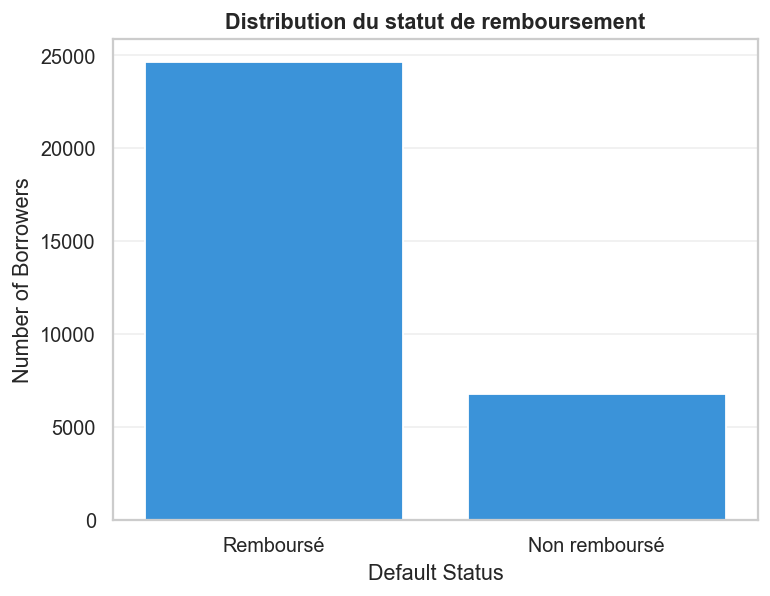

In [298]:
sns.countplot(x='Default Status', data=data, color='#2196F3')
plt.title('Distribution du statut de remboursement')
plt.xticks([0, 1], ['Remboursé', 'Non remboursé'])
plt.ylabel('Number of Borrowers')
plt.show()

Environ 21,5 % des clients de la banque sont en défaut de paiement, contre 78 % qui remboursent leurs prêts. Cela indique un déséquilibre du jeu de données, avec une majorité de cas de non-défaut.

Néanmoins, la proportion de défaut reste suffisamment élevée pour analyser les facteurs influençant le risque de crédit. Lors de la modélisation, il sera toutefois nécessaire de prendre en compte ce déséquilibre.

### Statistiques descriptives de l'Âge des clients

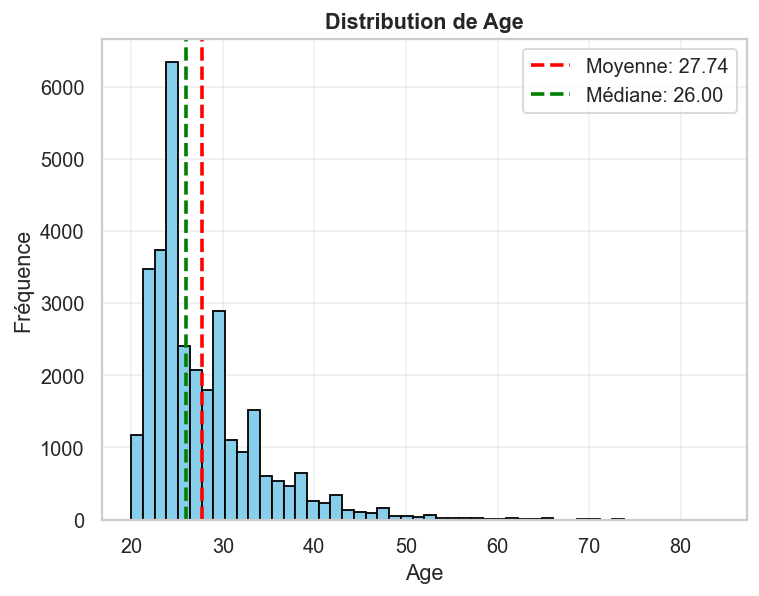

In [299]:
Statistique_Descriptives(data, "Age")

Un premier contrôle exploratoire montre que l'âge des individus est dans une fourchette assez raisonnable comprise entre 20 et 84 ans. Cela semble très normale vu la situation des individus et l'esperance de vie à la naissance. 

### Analyse du nombre d'année(s) de travail

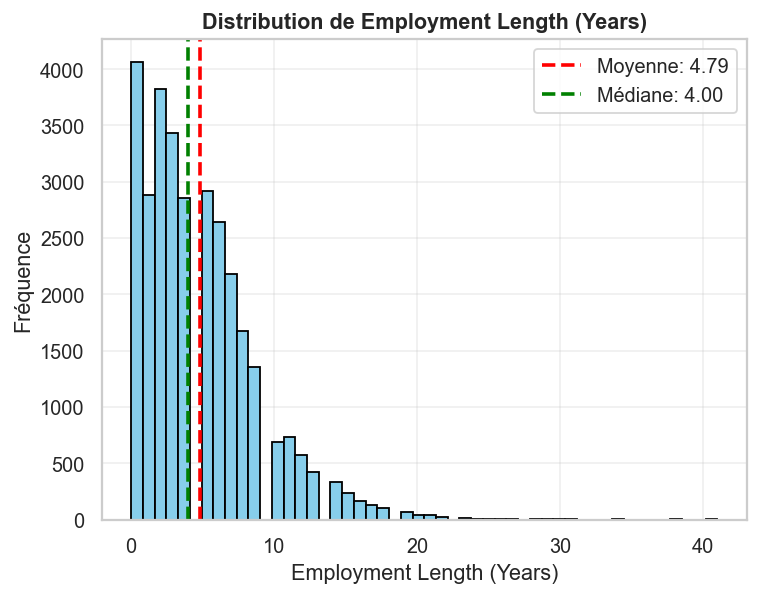

In [300]:
Statistique_Descriptives(data, "Employment Length (Years)")

Une analyse aussi de nombre d'année d'expérience des individus montre que cela est aussi normale avec la periode allant de 0 à 41 ans d'experience de travail.(<60 ans)

### Analyse des données des taux d'interet

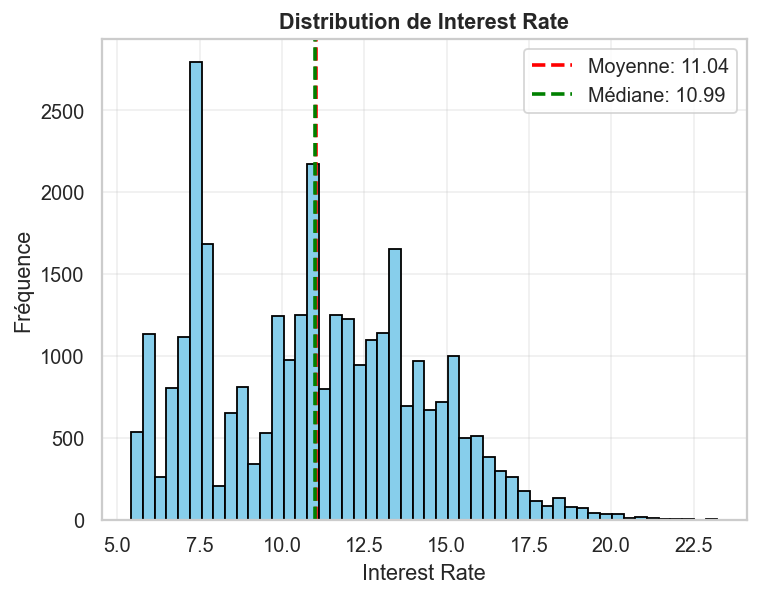

In [301]:
Statistique_Descriptives(data, "Interest Rate")

Les informations sur les taux d'interet montre que le mode est obtenus pour des valeurs proches de 7,5% ce qui reflète reellement la nature des taux d'interet sur les prèts bancaires. 

### Données sur les montants empruntés

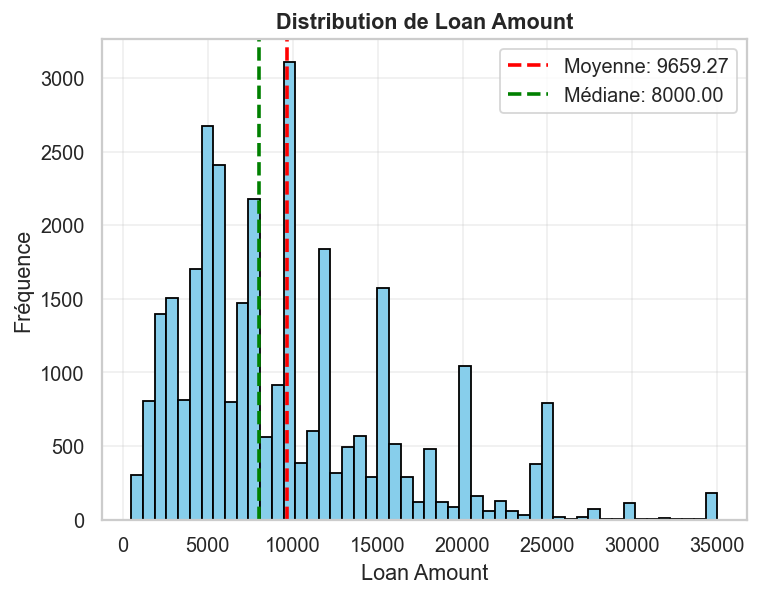

In [302]:
Statistique_Descriptives(data, "Loan Amount")

Le montant maximal des montants prets est de 35000 euros.

### Analyse des defaut précedement des clients

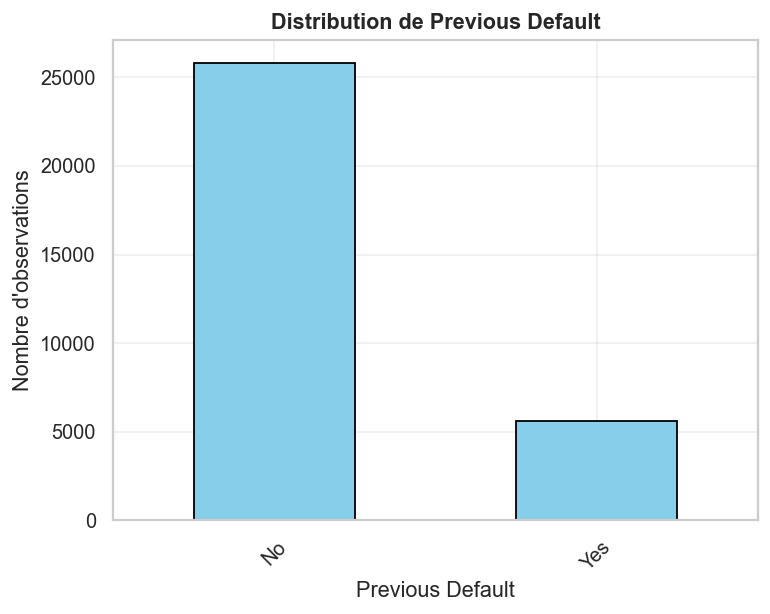

--- Previous Default ---
Previous Default
No     25830
Yes     5585
Name: count, dtype: int64




In [303]:
analyse_categorielle(data, "Previous Default")

Seulement 17,5% des clients avait fait un defaut sur leur credit precedemment.

### Analyse de Loan-to-Income Group (Montant du pret/Revenu)

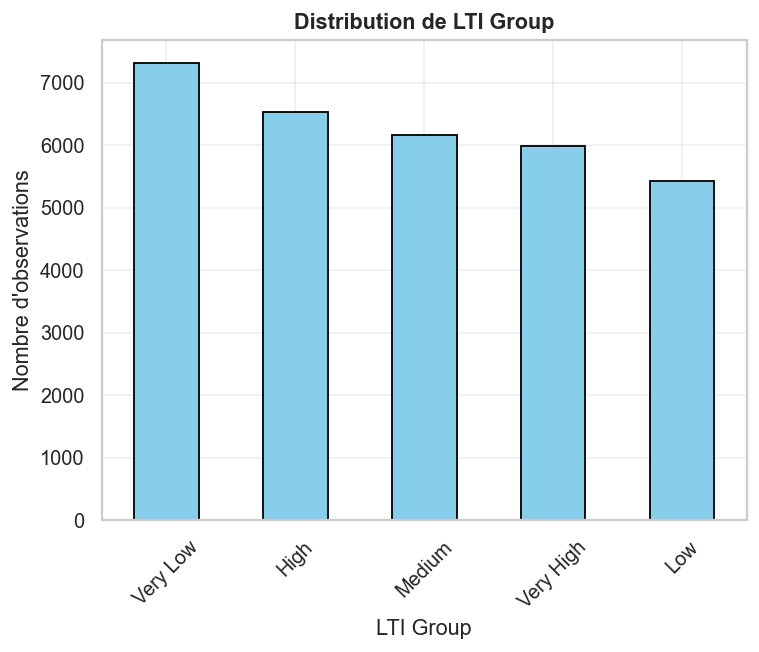

--- LTI Group ---
LTI Group
Very Low     7321
High         6528
Medium       6157
Very High    5981
Low          5428
Name: count, dtype: int64




In [304]:
analyse_categorielle(data, "LTI Group")

### Motifs de prêts (Loan Purpose)

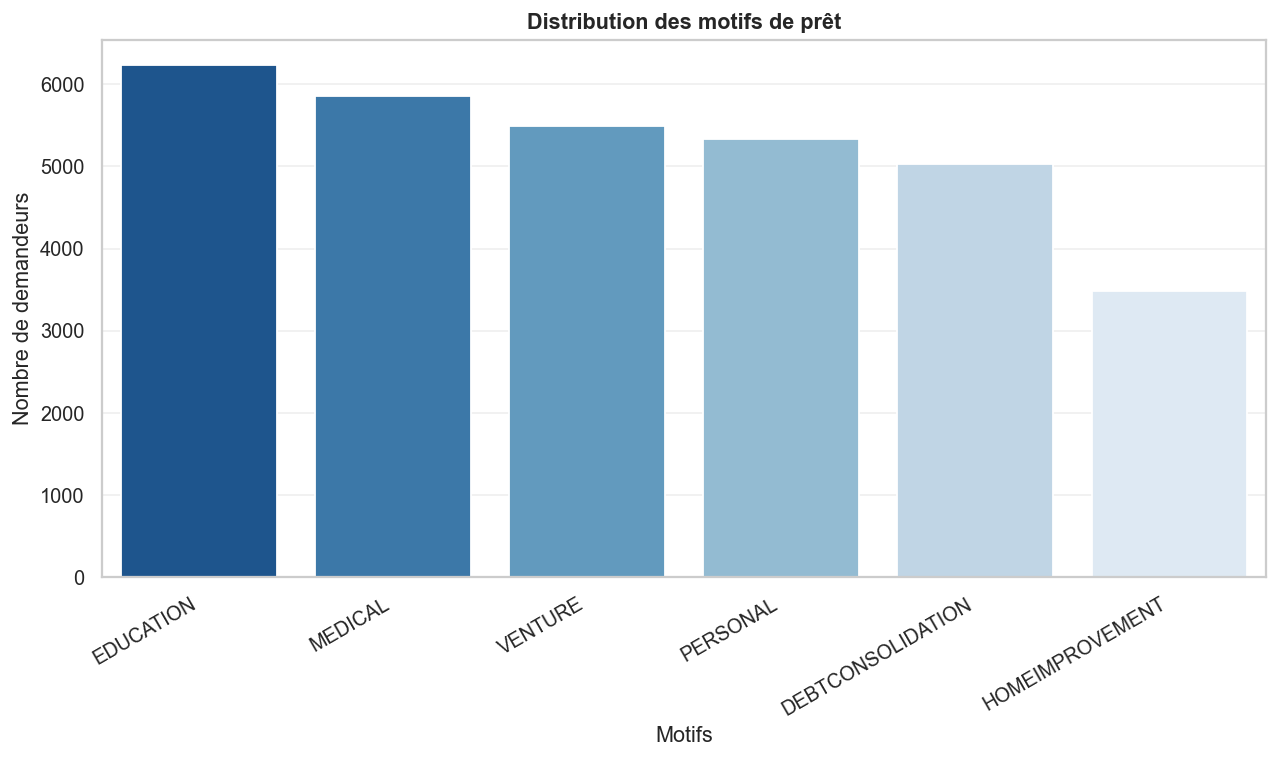

In [305]:

plt.figure(figsize=(10,6))

order = data['Loan Purpose'].value_counts().index

sns.countplot(
    data=data,
    x='Loan Purpose',
    order=order,
    palette='Blues_r'
)

plt.title('Distribution des motifs de prêt', fontsize=12)
plt.xlabel('Motifs')
plt.ylabel('Nombre de demandeurs')

plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()


La demande de prêts se répartit entre plusieurs motifs, les prêts destinés à l'éducation, aux soins médicaux, à l'entrepreneuriat et aux besoins personnels constituant les segments les plus importants.

Les prêts destinés à la rénovation immobilière semblent nettement moins importants, tandis que les prêts de regroupement de dettes continuent de représenter une part significative.

### Notation de Prêt (Loan Grade)

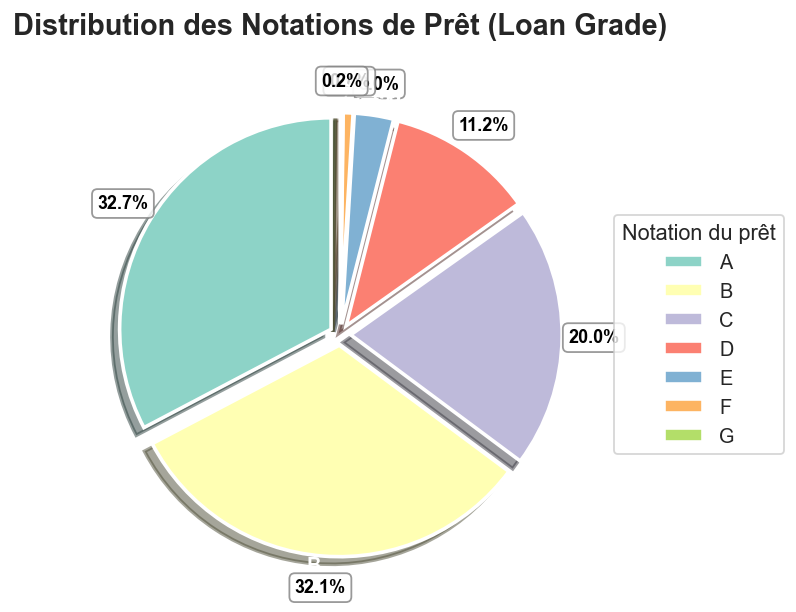

In [306]:
import matplotlib.pyplot as plt

# Calcul des statistiques par grade
grade_stats = (
    data.groupby('Loan Grade')['Default Status']
    .agg(Default_Rate='mean', Count='count')
    .reset_index()
)

# Création des labels intérieurs (grade + effectif)
labels_interieurs = [
    f"{grade}\n(n={count})"
    for grade, count in zip(grade_stats['Loan Grade'], grade_stats['Count'])
]

# Figure
fig, ax = plt.subplots(figsize=(6, 6))

# Palette 
colors = plt.cm.Set3.colors[:len(grade_stats)]

# Explosion légère
explode = [0.05] * len(grade_stats)

# Camembert
wedges, texts, autotexts = ax.pie(
    grade_stats['Count'],
    labels=labels_interieurs,
    autopct='%1.1f%%',
    startangle=90,
    pctdistance=1.15,
    colors=colors,
    explode=explode,
    textprops={'fontsize': 11, 'weight': 'bold', 'color': 'white'},
    wedgeprops={'edgecolor': 'white', 'linewidth': 2},
    shadow=True
)

# Style des pourcentages
for autotext in autotexts:
    autotext.set_color('black')
    autotext.set_fontsize(10)
    autotext.set_bbox(dict(
        boxstyle='round,pad=0.3',
        facecolor='white',
        edgecolor='gray',
        alpha=0.8
    ))

# Titre
ax.set_title(
    "Distribution des Notations de Prêt (Loan Grade)",
    fontsize=16,
    fontweight='bold',
    pad=20
)

# Légende
ax.legend(
    wedges,
    grade_stats['Loan Grade'],
    title="Notation du prêt",
    loc="center left",
    bbox_to_anchor=(1, 0.5)
)

plt.tight_layout()
plt.show()

### Interprétation

**Analyse de la répartition:**
- La majorité des emprunteurs reçoivent une notation entre A et C (environ 75 %), indiquant que la plupart des demandes de prêt proviennent de profils considérés comme moins risqués.
- Les grades D, E, F et G représentent une proportion plus faible, correspondant aux profils plus risqués.

**Effectivité de la notation:**
- La notation du prêt **reflète efficacement le risque de défaut**: on observe une tendance croissante du taux de défaut avec la dégradation de la notation.
- Les grades supérieurs (meilleure notation = moins de risque) ont les taux de défaut les plus bas.
- Les grades inférieurs (pire notation = plus de risque) ont les taux de défaut les plus élevés.
- Cette progression monotone confirme que le système de notation discrimine bien les emprunteurs en fonction de leur risque de défaut.

### Statut du logement (Home Ownership)

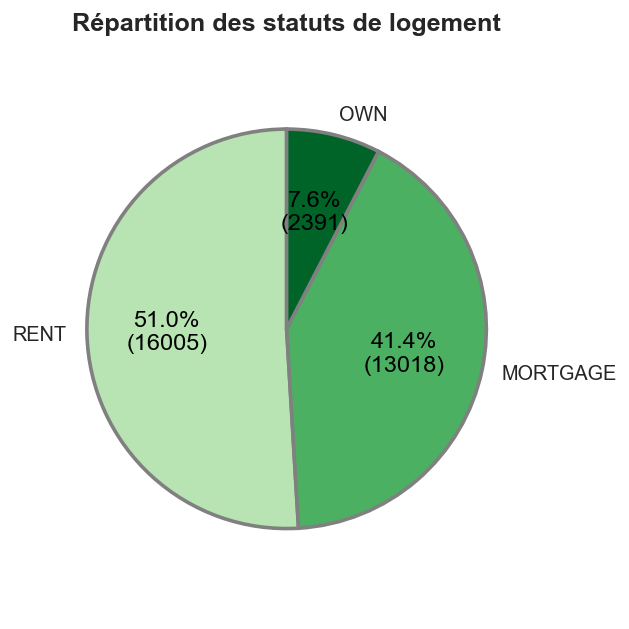

In [307]:

# Distribution des fréquences des différents statuts de logement.
level_counts = data['Home Ownership'].value_counts()
colors = plt.cm.Greens(np.linspace(0.3, 0.9, len(level_counts)))

fig, ax = plt.subplots(figsize=(5, 5))

wedges, texts, autotexts = ax.pie(
    level_counts.values,
    labels=level_counts.index,
    autopct=lambda pct: f'{pct:.1f}%\n({int(pct/100*sum(level_counts.values))})',
    colors=colors,
    textprops={'fontsize': 11},
    wedgeprops={'edgecolor': 'gray', 'linewidth': 2},
    startangle=90
)

for autotext in autotexts:
    autotext.set_fontsize(13)
    autotext.set_color('black')

ax.set_title('Répartition des statuts de logement', fontsize=14, fontweight='bold')
ax.axis('equal')
plt.tight_layout()
plt.show()

- La plupart des personnes qui contractent un prêt ne sont pas propriétaires de leur logement
- Le graphique montre la répartition des modes d'occupation du logement parmi les emprunteurs : les locataires constituent le groupe le plus important, suivis des détenteurs d'un prêt immobilier, tandis qu'une proportion plus faible est propriétaire de son logement.

### Detection d'outliers

Les valeurs aberrantes ont été détectées à l’aide de boxplots et de la méthode de l’IQR.Pour les variables financières (revenu, montant du prêt, taux d’intérêt, etc.), les valeurs extrêmes ont été conservées car elles reflètent la réalité. Ces variables sont asymétriques à droite à cause de quelques valeurs très élevées. Garder ces valeurs permet de mieux analyser les profils à haut revenu ou à risque élevé. Leur présence montre une forte hétérogénéité des emprunteurs, ce qui est normal dans ce type de données.

In [309]:
# Colonnes sélectionnées pour l'analyse des valeurs aberrantes
cols = ["Annual Income",'Loan Amount', 'Interest Rate', 'Loan % of Income','Credit History Length (Years)']

# Fonction pour détecter les valeurs aberrantes avec la méthode de l'intervalle interquartile (IQR)
def detect_outliers_iqr(data, col):
    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = data[(data[col] < lower) | (data[col] > upper)]
    return len(outliers), lower, upper

# Affiche un résumé des valeurs aberrantes pour chaque colonne
for col in cols:
    count, low, high = detect_outliers_iqr(data, col)
    print(f"{col}: {count} valeurs aberrantes ({(count/len(data))*100:.2f}%) | intervalle [{low:.2f}, {high:.2f}]")
    print()

Annual Income: 1448 valeurs aberrantes (4.61%) | intervalle [-21475.00, 140885.00]

Loan Amount: 1621 valeurs aberrantes (5.16%) | intervalle [-6250.00, 23750.00]

Interest Rate: 6 valeurs aberrantes (0.02%) | intervalle [-0.47, 21.85]

Loan % of Income: 610 valeurs aberrantes (1.94%) | intervalle [-0.12, 0.44]

Credit History Length (Years): 1108 valeurs aberrantes (3.53%) | intervalle [-4.50, 15.50]



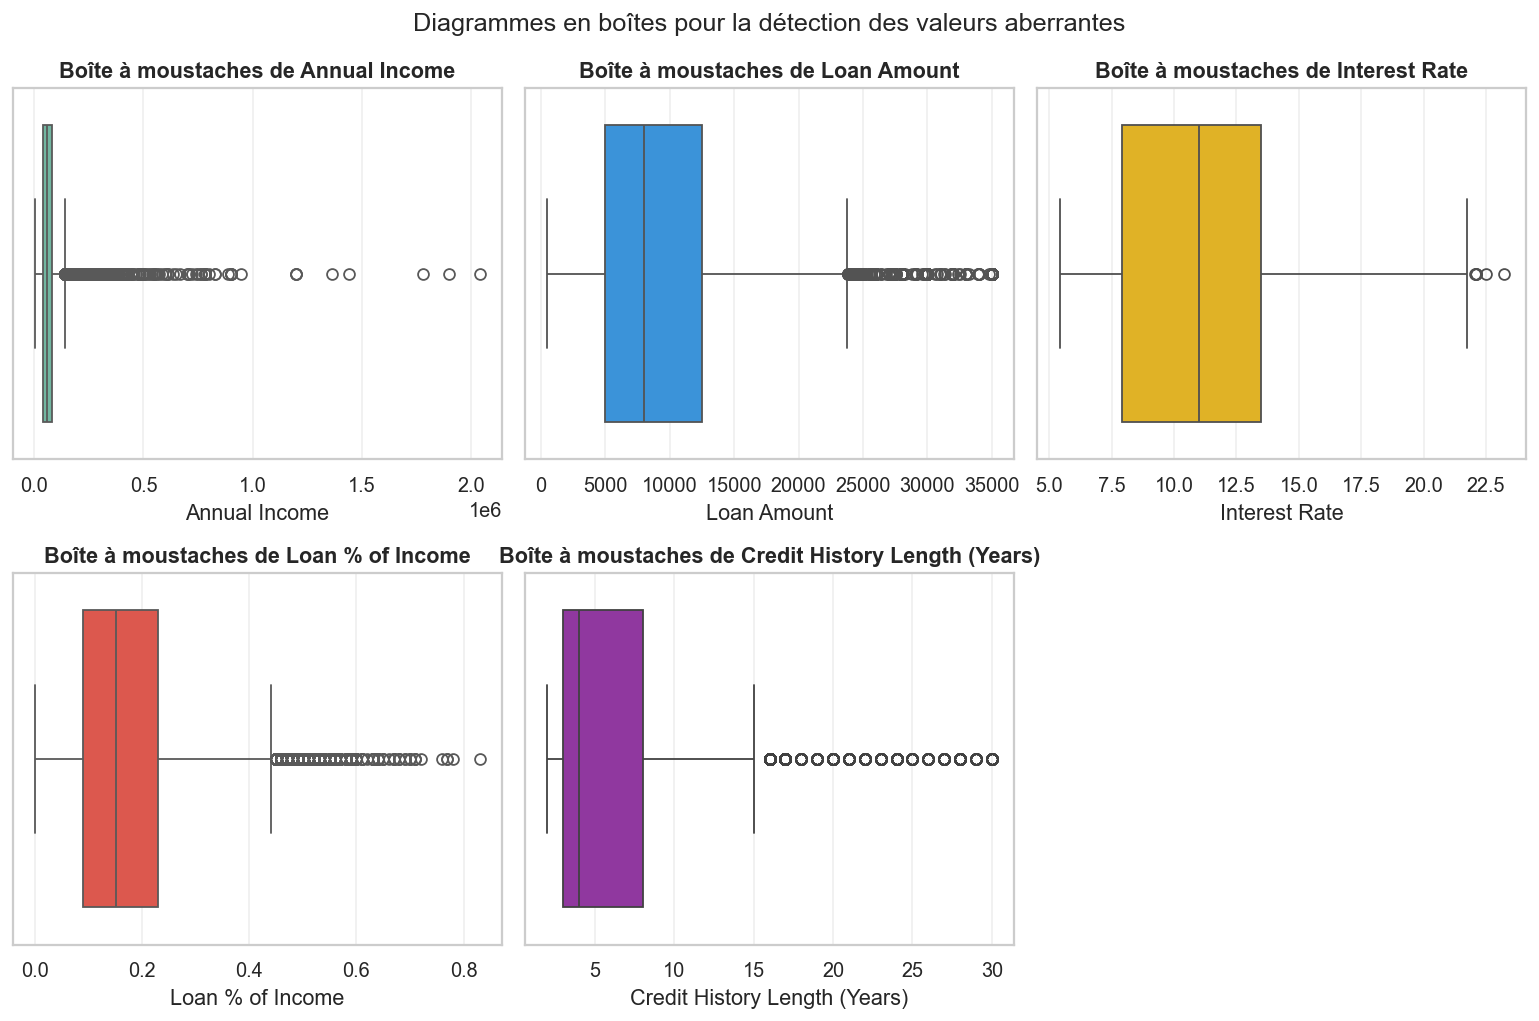

In [310]:
# Visualise les distributions à l'aide de diagrammes en boîtes (boxplots)
colors = ['#66c2a5','#2196F3', '#FFC107', '#F44336', '#9C27B0']
plt.figure(figsize=(12,8))

for i, col in enumerate(cols):
    plt.subplot(2, 3, i + 1)   # i+1 pour que l'indice du sous-graphe soit basé sur 1
    sns.boxplot(x=data[col], color=colors[i])   # utilise 'i' pour sélectionner la couleur
    plt.title(f'Boîte à moustaches de {col}')
    plt.xlabel(col)

plt.suptitle('Diagrammes en boîtes pour la détection des valeurs aberrantes', fontsize=14)
plt.tight_layout()
plt.show()

# II. Statistique descriptives bivariées

In [311]:
from statistique_descriptive import bivarié_cat_num
from statistique_descriptive import bivarié_cat_cat
from scipy import stats

## II.1 Interaction des caractéristiques catégorielles sur la variable d'intérêt

### Objectif n°1: Comment la notation des prêts reflète-t-elle efficacement le risque de défaut de paiement de l'emprunteur?

In [312]:
def default_summary(data, group_col):
    return data.groupby(group_col).agg(
        # Nombre total d'emprunteurs dans chaque groupe (taille de l'échantillon — critique pour la fiabilité)
        total=('Default Status', 'count'),

        # Nombre d'emprunteurs ayant fait défaut (somme des 1 dans la cible binaire)
        defaults=('Default Status', 'sum'),

        # Taux de défaut = moyenne de la cible binaire = proportion de défauts dans le groupe
        default_rate=('Default Status', 'mean'),

        # Borne inférieure de l'intervalle de confiance à 95% pour le taux de défaut.
        # Utilise un intervalle de Wald (approximation normale) via statsmodels.proportion_confint.
        # Des intervalles plus larges signalent des estimations moins fiables (généralement pour les petits groupes).
        ci_lower=('Default Status', lambda x: proportion_confint(x.sum(), len(x), alpha=0.05)[0]),

        # Borne supérieure de l'intervalle de confiance à 95% pour le taux de défaut.
        ci_upper=('Default Status', lambda x: proportion_confint(x.sum(), len(x), alpha=0.05)[1])
    ).reset_index()  # Aplatit l'index du groupby en une colonne ordinaire pour un affichage facile

In [313]:
#résumé par grade de prêt
pd.set_option('display.float_format', '{:,.2f}'.format)
default_summary(data, 'Loan Grade')

,Loan Grade,total,defaults,default_rate,ci_lower,ci_upper
0,A,10274,982,0.10,0.09,0.10
1,B,10088,1611,0.16,0.15,0.17
2,C,6283,1274,0.20,0.19,0.21
3,D,3529,2075,0.59,0.57,0.60
4,E,943,605,0.64,0.61,0.67
5,F,234,164,0.70,0.64,0.76
6,G,64,63,0.98,0.95,1.00


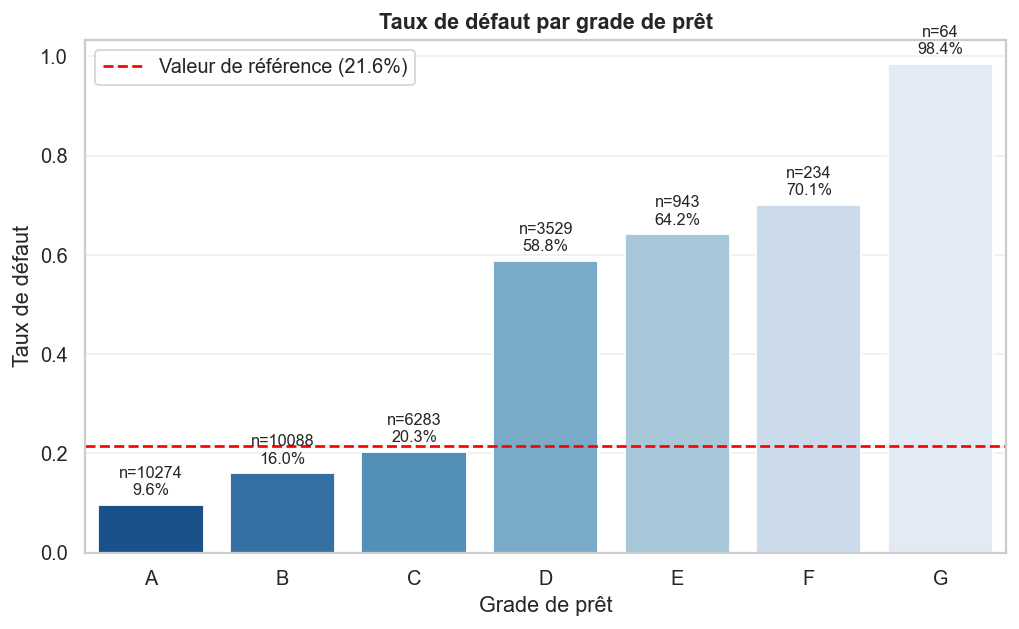

In [314]:
# Calcule le taux de défaut par grade de prêt
grade_stats = data.groupby('Loan Grade')['Default Status'].agg(['mean', 'count']).reset_index()

# Renomme pour plus de clarté
grade_stats.columns = ['Loan Grade', 'Default Rate', 'Count']

# Taux de base global
baseline = data['Default Status'].mean()

plt.figure(figsize=(8,5))

# Diagramme en barres avec une palette de couleurs modifiée
# Exemples : 'Blues_r', 'Reds_r', 'coolwarm', 'viridis', 'Set2', 'muted', 'pastel'
sns.barplot(
    data=grade_stats,
    x='Loan Grade',
    y='Default Rate',
    palette='Blues_r'      # ← Couleurs modifiées : dégradé de bleu (plus foncé pour les grades élevés)
)

# Ajoute la ligne du taux de base
plt.axhline(baseline, linestyle='--', color='red', label=f'Valeur de référence ({baseline:.1%})')

# Ajoute les annotations (taux + taille de l'échantillon)
for i, row in grade_stats.iterrows():
    plt.text(i, row['Default Rate'] + 0.02,
             f"n={int(row['Count'])}\n{row['Default Rate']:.1%}",
             ha='center', fontsize=9)

plt.title('Taux de défaut par grade de prêt', fontsize=12)  # Titre en français
plt.ylabel('Taux de défaut')
plt.xlabel('Grade de prêt')
plt.legend()

plt.tight_layout()
plt.show()

### interprétation:
1. Observation des tendances
- Le graphique montre une séparation très nette entre les grades A–C (faible risque) et D–G (risque élevé) :
- Grades A, B, C : taux de défaut compris entre environ 12 % et 20 %.
- Grades D, E, F : taux de défaut beaucoup plus élevés, de 58 % à 72 %.
- Le taux de défaut de référence global est de 21,6 %.
- Cette rupture brutale entre C et D indique que le système de notation ne suit pas une échelle linéaire, mais intègre probablement un seuil de risque strict (par exemple, un score minimum imposé par les politiques de prêt).

2. Déséquilibre des effectifs
- La majorité des prêts (n=10 274 pour A ) se concentre sur les grades A–C.
- Les grades à haut risque (D–F) ne représentent qu’un faible nombre d’observations (par exemple n=943 pour E, n=234 pour F, etc.).
- Ce déséquilibre reflète une stratégie de prêt réaliste : les institutions évitent d’accorder massivement des prêts aux profils les plus risqués.

3. Limites méthodologiques
- Les petits effectifs dans les grades D–F rendent les estimations de taux de défaut moins fiables (intervalles de confiance larges). Une interprétation prudente s’impose.
- La valeur de référence globale (21,6 %) est tirée vers le bas par la surreprésentation des grades A–C.

4. Conclusion stratégique
 Le grade de prêt est un indicateur puissant et synthétique du risque de défaut. Il agrège efficacement des informations financières et comportementales des emprunteurs. Pour une gestion du risque optimale :
- Renforcer la segmentation : traiter les grades A–C et D–G comme deux populations distinctes dans les modèles de scoring.
- Collecter plus de données sur les grades D–G pour affiner les estimations.
- Envisager des seuils d’acceptation plus stricts si le taux de défaut observé (>58 %) est jugé trop élevé.

### Correlation des variables numériques avec l'échellon du pret

In [315]:
grade_numeric = {'A': 1, 'B': 2, 'C': 3, 'D': 4, 'E': 5, 'F': 6, 'G': 7}
data['grade_numeric'] = data['Loan Grade'].map(grade_numeric)
features = {
    'Annual Income': 'Income',
    'Loan % of Income': 'LTI',
    'Employment Length (Years)': 'Employment Length',
    'Credit History Length (Years)': 'Credit History'
}

print(f"{'Variable':<25} {'Correlation avec Loan Grade':<25} {'R²':<10}")
print("-" * 60)

for col, label in features.items():
    r, p = stats.pearsonr(data['grade_numeric'], data[col])
    print(f"{label:<25} {r:<25.4f} {r**2:<10.4f}")

prev_numeric = (data['Previous Default'] == 'Yes').astype(int)
r, p = stats.pearsonr(data['grade_numeric'], prev_numeric)
print(f"{'Previous Default':<25} {r:<25.4f} {r**2:<10.4f}")

Variable                  Correlation avec Loan Grade R²        
------------------------------------------------------------
Income                    -0.0066                   0.0000    
LTI                       0.1241                    0.0154    
Employment Length         -0.0487                   0.0024    
Credit History            0.0133                    0.0002    
Previous Default          0.5359                    0.2872    


### Objectif n°2 : Le motif du prêt est-il lié au défaut de paiement ?

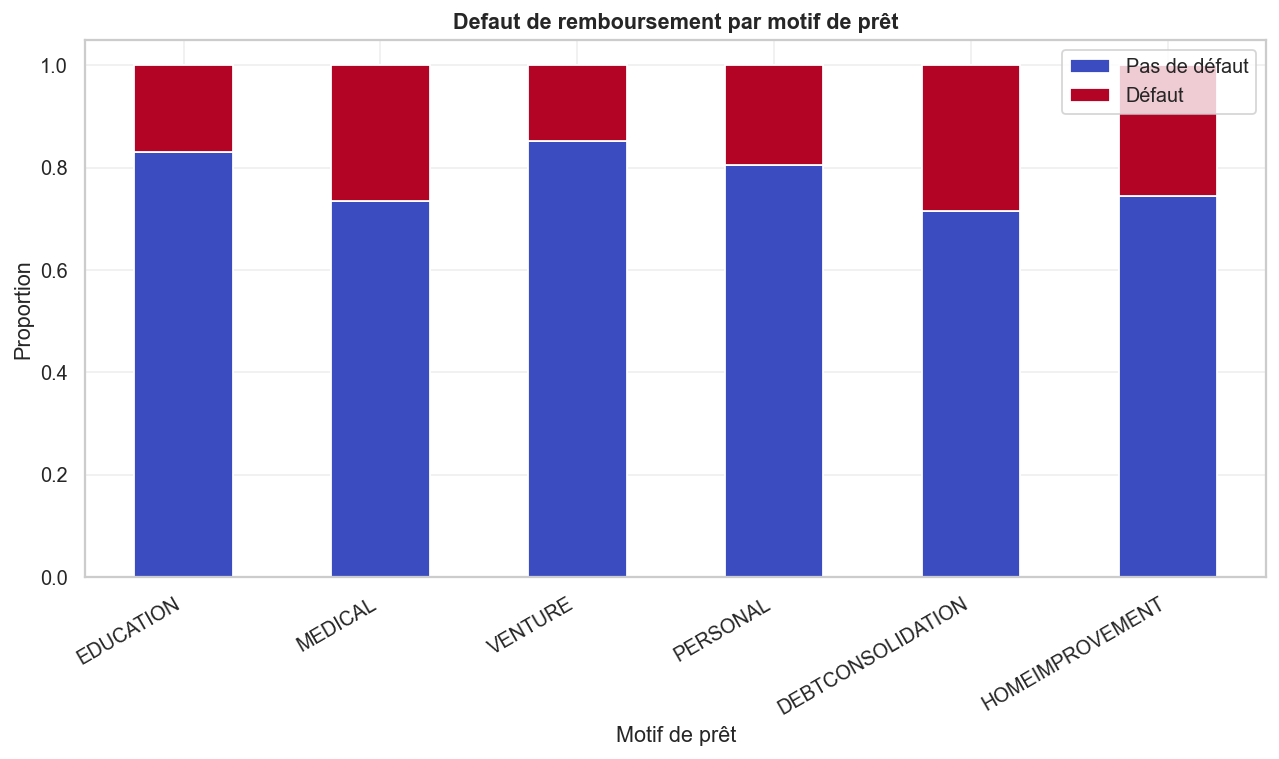

In [316]:
ct = pd.crosstab(
    data['Loan Purpose'],
    data['Default Status'],
    normalize='index'
)

ct = ct.loc[order]

ct.plot(
    kind='bar',
    stacked=True,
    figsize=(10,6),
    colormap='coolwarm'
)

plt.title('Defaut de remboursement par motif de prêt')
plt.ylabel('Proportion')
plt.xlabel('Motif de prêt')
plt.xticks(rotation=30, ha='right')
plt.legend(['Pas de défaut', 'Défaut'])
plt.tight_layout()
plt.show()


Les taux de défaut varient selon l'objet du prêt :
- Certaines catégories (par exemple, les prêts médicaux, les prêts personnels, les prêts pour la rénovation) affichent des taux de défaut relativement plus élevés
- D'autres (par exemple, les prêts pour les études, les prêts à risque) semblent plus stables, avec des taux de défaut plus faibles

Toutefois, ces différences ne sont pas très marquées, et il n'y a pas de démarcation nette entre les catégories.

### Objectif N° 3: Le statut de logement (propriétaire, locataire, etc.) influence le risque de défaut de paiement.

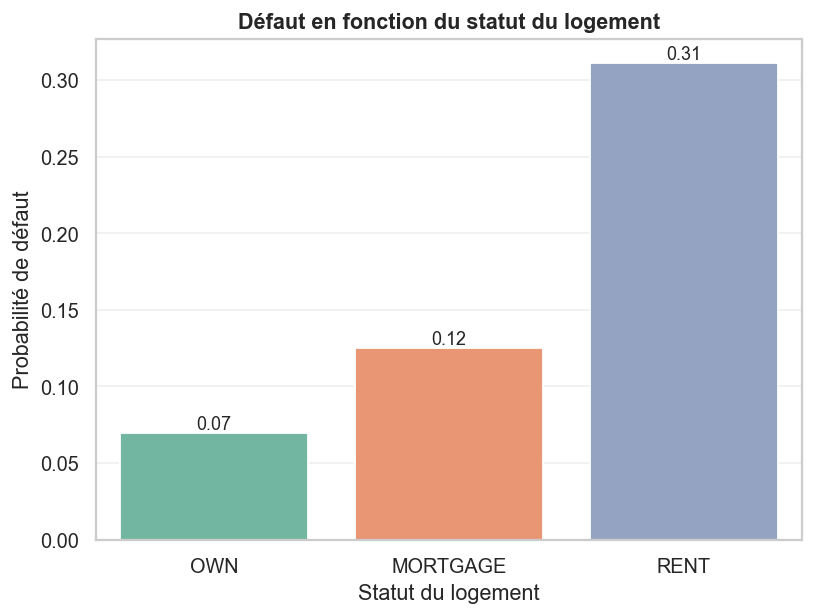

In [317]:
plt.figure(figsize=(7,5))

ax = sns.barplot(
    x='Home Ownership',
    y='Default Status',
    data=data,
    palette = ['#66C2A5', '#FC8D62', '#8DA0CB'],
    errorbar=None
)

# Add labels
for p in ax.patches:
    ax.annotate(f'{p.get_height():.2f}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=10)

plt.title('Défaut en fonction du statut du logement')
plt.xlabel('Statut du logement')
plt.ylabel('Probabilité de défaut')
plt.show()


- Le statut de propriétaire est étroitement lié au risque de défaut de paiement. Les emprunteurs propriétaires affichent des taux de défaut nettement inférieurs à ceux des locataires. Les détenteurs d'un prêt hypothécaire présentent un risque de défaut modéré, tandis que les locataires affichent les taux de défaut les plus élevés parmi les principaux groupes.

- Cette tendance suggère que l'accession à la propriété sert d'indicateur de la stabilité financière et de la solvabilité.

### Objectif n° 4: Les antécédents de défaut de paiement d'un emprunteur influencent-ils de manière significative le risque de défaut de paiement futur ?

In [318]:
(data['Previous Default'].value_counts(normalize=True) * 100).round(1)

Previous Default
No    82.20
Yes   17.80
Name: proportion, dtype: float64

- L'ensemble de données présente un déséquilibre : environ 82 % des emprunteurs n'ont jamais été en défaut de paiement, tandis que 18 % l'ont déjà été.

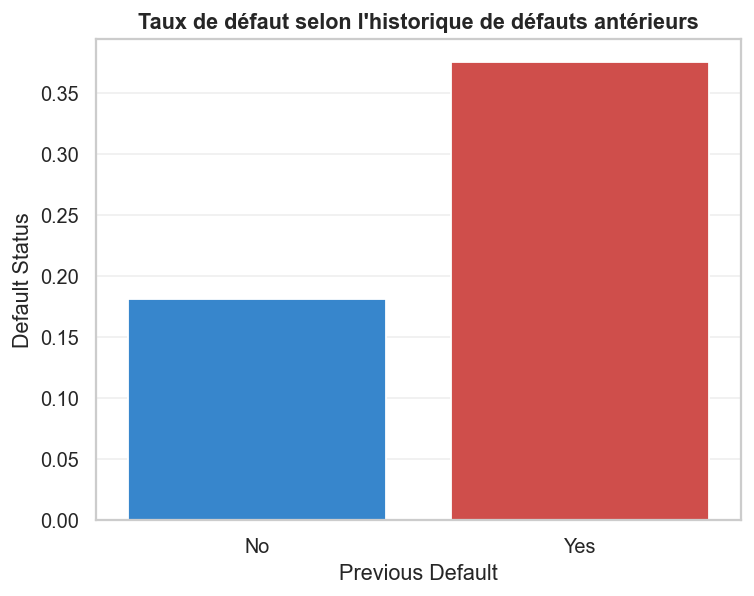

In [319]:
# Ce graphique visualise les taux de défaut selon que l'emprunteur a ou non un historique de défauts antérieurs.
sns.barplot(x='Previous Default', y='Default Status', data=data, errorbar=None, palette=['#1E88E5', '#E53935'])
plt.title('Taux de défaut selon l\'historique de défauts antérieurs')
plt.show()

- Bien qu'ils soient minoritaires, les emprunteurs ayant déjà été en défaut de paiement affichent un taux de défaut nettement plus élevé (37 à 38 %) que ceux qui n'ont pas d'antécédents en la matière (~18 %).
- L'écart entre les deux groupes est important et clairement visible : il n'y a ni chevauchement ni ambiguïté dans la tendance.

### Conclusion

- Les antécédents de défaut constituent l'un des facteurs prédictifs les plus puissants de l'ensemble de données.
- Ils fournissent un indicateur clair et immédiat du risque, sans nécessiter de traitement supplémentaire ni d'ingénierie des caractéristiques.
- Du point de vue de la modélisation ou de la prise de décision, cette variable doit être considérée comme hautement prioritaire, car elle reflète directement la fiabilité de l'emprunteur.

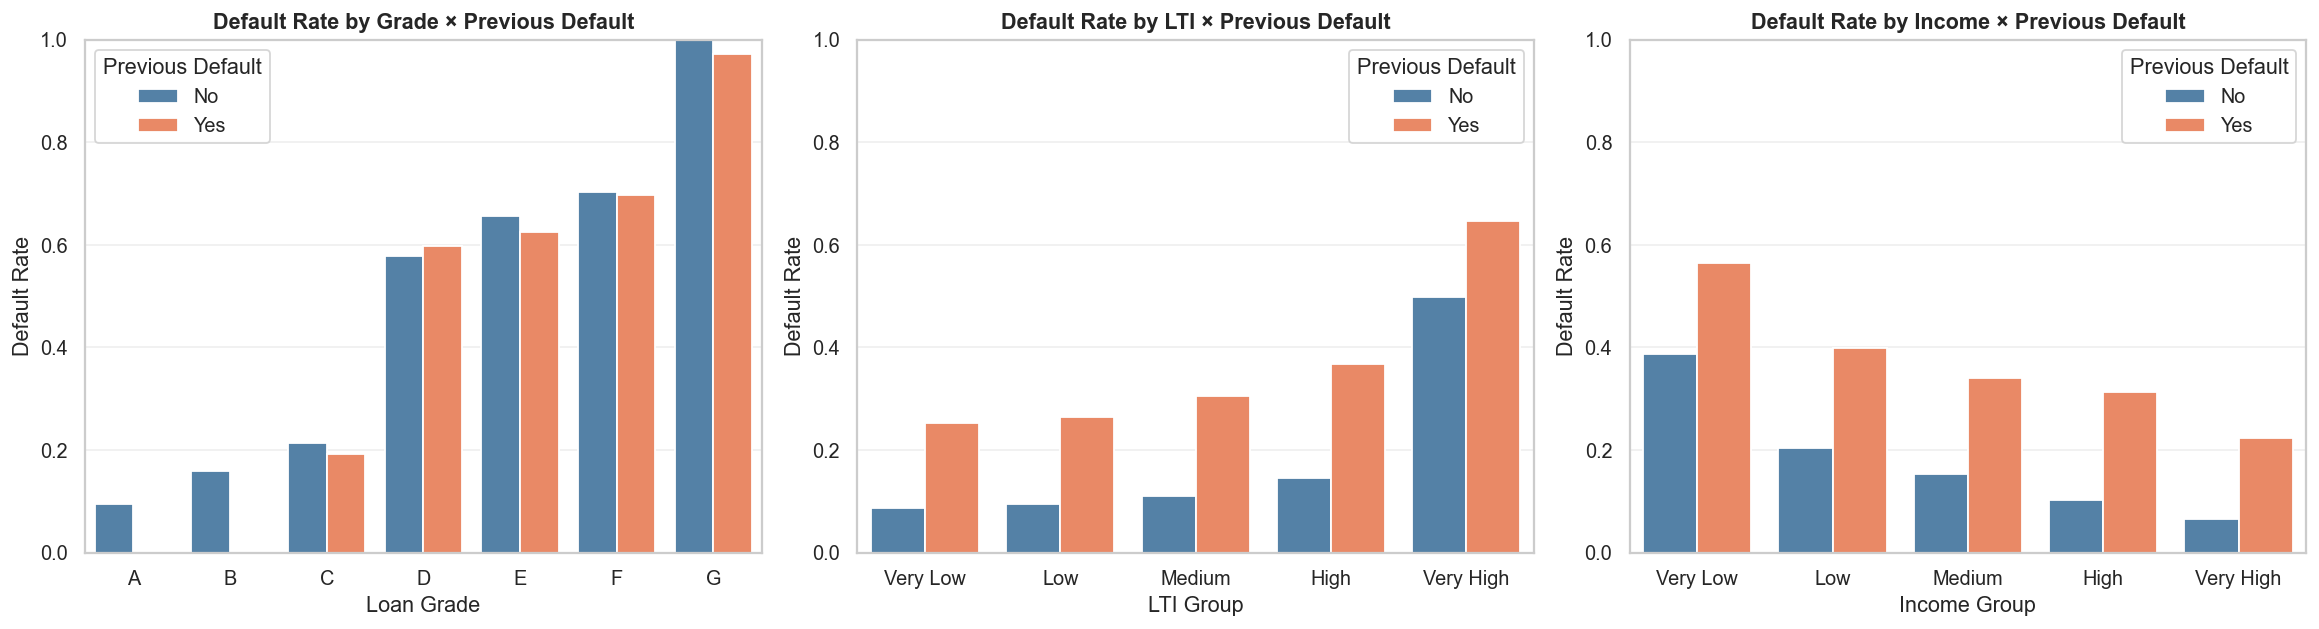

In [320]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Créer le groupe LTI avant de l'utiliser
data['LTI Group'] = pd.qcut(data['Loan % of Income'], q=5, labels=["Very Low","Low","Medium","High","Very High"])

# Créer le groupe de revenu avant de l'utiliser
data['Income Group'] = pd.qcut(data['Annual Income'], q=5, labels=['Very Low', 'Low', 'Medium', 'High', 'Very High'])

# 1. Défaut antérieur × Grade de prêt
grade_order = ['A', 'B', 'C', 'D', 'E', 'F', 'G']
grouped1 = (data.groupby(['Loan Grade', 'Previous Default'])['Default Status']
              .mean()
              .reset_index()
              .rename(columns={'Default Status': 'default_rate'}))

sns.barplot(data=grouped1, x='Loan Grade', y='default_rate',
            hue='Previous Default', order=grade_order,
            ax=axes[0], palette=['steelblue', 'coral'])
axes[0].set_title('Default Rate by Grade × Previous Default')
axes[0].set_xlabel('Loan Grade')
axes[0].set_ylabel('Default Rate')
axes[0].set_ylim(0, 1)

# 2. Défaut antérieur × Groupe LTI
grouped2 = (data.groupby(['LTI Group', 'Previous Default'])['Default Status']
              .mean()
              .reset_index()
              .rename(columns={'Default Status': 'default_rate'}))

lti_order = ['Very Low', 'Low', 'Medium', 'High', 'Very High']
sns.barplot(data=grouped2, x='LTI Group', y='default_rate',
            hue='Previous Default', order=lti_order,
            ax=axes[1], palette=['steelblue', 'coral'])
axes[1].set_title('Default Rate by LTI × Previous Default')
axes[1].set_xlabel('LTI Group')
axes[1].set_ylabel('Default Rate')
axes[1].set_ylim(0, 1)

# 3. Défaut antérieur × Groupe de revenu
grouped3 = (data.groupby(['Income Group', 'Previous Default'])['Default Status']
              .mean()
              .reset_index()
              .rename(columns={'Default Status': 'default_rate'}))

income_order = ['Very Low', 'Low', 'Medium', 'High', 'Very High']
sns.barplot(data=grouped3, x='Income Group', y='default_rate',
            hue='Previous Default', order=income_order,
            ax=axes[2], palette=['steelblue', 'coral'])
axes[2].set_title('Default Rate by Income × Previous Default')
axes[2].set_xlabel('Income Group')
axes[2].set_ylabel('Default Rate')
axes[2].set_ylim(0, 1)

plt.tight_layout()
plt.show()

Trois tendances distinctes se dégagent :

Note : un défaut antérieur n'apporte qu'un signal supplémentaire minime au sein des notes — l'écart entre les emprunteurs ayant déjà fait défaut et ceux n'ayant jamais fait défaut est proche de zéro pour les notes D à G, ce qui confirme que la note intègre déjà la majeure partie du signal de risque comportemental (ce qui concorde avec un R² = 28,76 % entre la note et le défaut antérieur).

LTI : les antécédents de défaut s'ajoutent systématiquement au poids de la dette — un écart d'environ 15 à 20 points de pourcentage persiste dans tous les groupes de LTI, s'élargissant dans la catégorie « LTI très élevé » où les deux facteurs de risque atteignent simultanément leur pic.

Revenu : les antécédents de défaut sont indépendants du revenu — même les emprunteurs à revenu très élevé ayant déjà fait défaut sont confrontés à un taux de défaut de 23 %, près de quatre fois supérieur à celui de leurs homologues sans antécédents de défaut (6 %).

Implication : les antécédents de défaut constituent un signal comportemental indépendant par rapport au revenu et au LTI, mais sont largement pris en compte dans la notation de crédit. Dans un modèle prédictif incluant la notation, la contribution marginale des antécédents de défaut doit être validée — sa valeur indépendante pourrait se limiter aux segments d'emprunteurs qui ne sont pas clairement distingués par la seule notation.

### Default rate versus Age Group

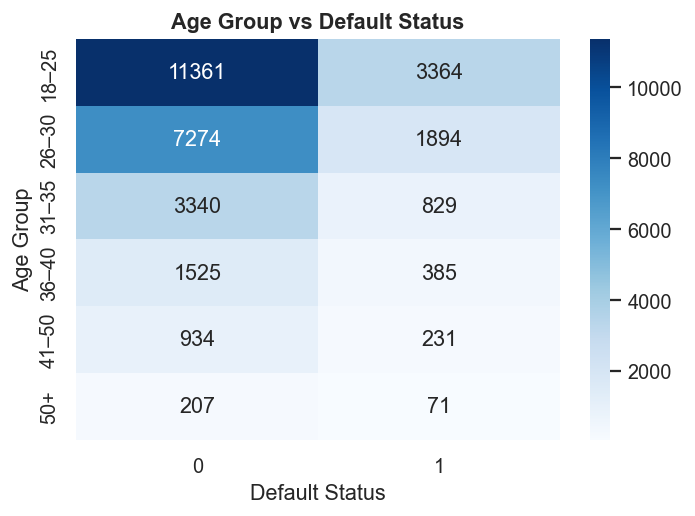

Default Status      0     1
Age Group                  
18–25           11361  3364
26–30            7274  1894
31–35            3340   829
36–40            1525   385
41–50             934   231
50+               207    71


In [321]:
bivarié_cat_cat(data, "Age Group", "Default Status")

On remarque que les groupes d'age les plus en defaut de paiements sont les plus jeunes agée de 18 à 25 ans.

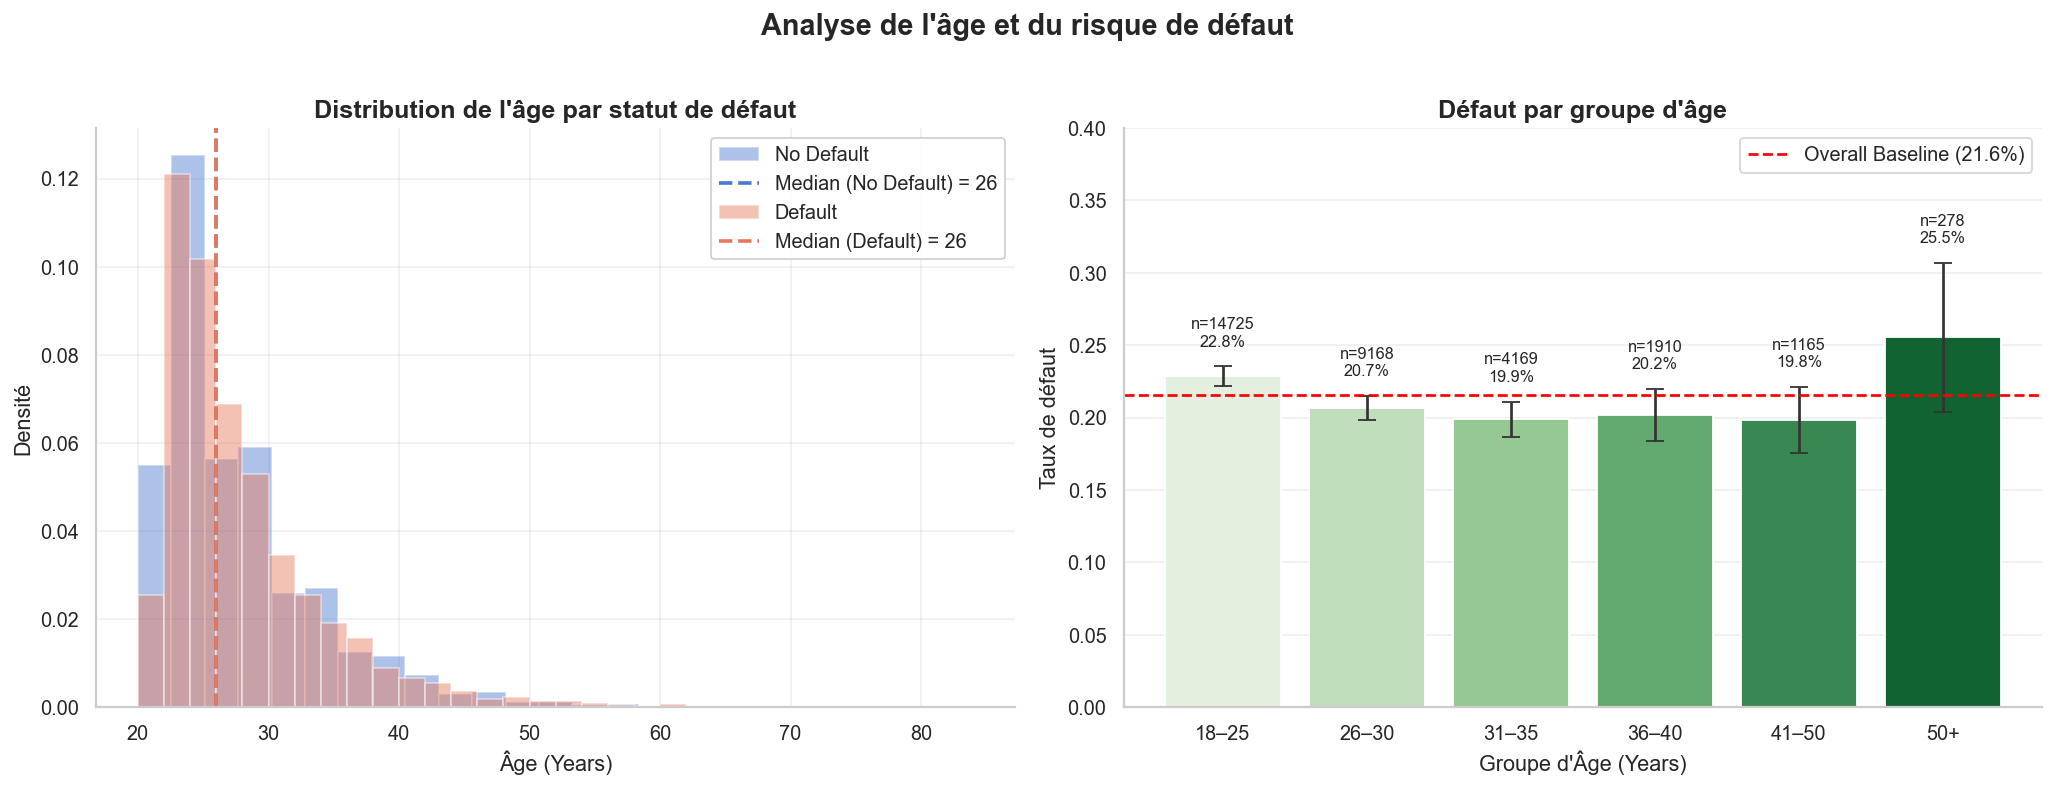

In [322]:
plt.rcParams.update({
    'font.size': 13,
    'axes.titlesize': 14,
    'axes.titleweight': 'bold',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'figure.dpi': 130,
})

BLUE  = '#4878CF'
CORAL = '#E8785A'

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Analyse de l\'âge et du risque de défaut', fontsize=16, fontweight='bold', y=1.01)

# ── GAUCHE : Histogramme normalisé + lignes des médianes ─────────────────────────────
for status, label, color in [(0, 'No Default', BLUE), (1, 'Default', CORAL)]:
    subset = data[data['Default Status'] == status]['Age']

    axes[0].hist(subset, bins=25, density=True,
                 alpha=0.45, color=color, label=label, edgecolor='white')

    median_val = subset.median()
    axes[0].axvline(median_val, color=color, linestyle='--',
                    linewidth=2, label=f'Median ({label}) = {median_val:.0f}')

axes[0].set_title('Distribution de l\'âge par statut de défaut')
axes[0].set_xlabel('Âge (Years)')
axes[0].set_ylabel('Densité')
axes[0].legend(fontsize=11, framealpha=0.9)

# ── DROITE : Taux de défaut par groupe d'âge + barres d'erreur (IC) + ligne de base ──────────
data['Age Group'] = pd.cut(
    data['Age'],
    bins=[18, 25, 30, 35, 40, 50, 100],
    labels=['18–25', '26–30', '31–35', '36–40', '41–50', '50+']
)

age_summary = (
    data.groupby('Age Group', observed=True)['Default Status']
    .agg(
        total='count',
        defaults='sum',
        default_rate='mean'
    )
    .reset_index()
)

# Intervalles de confiance
ci = age_summary.apply(
    lambda row: proportion_confint(row['defaults'], row['total'], alpha=0.05),
    axis=1
)
age_summary['ci_lower'] = ci.apply(lambda x: x[0])
age_summary['ci_upper'] = ci.apply(lambda x: x[1])

yerr = [
    age_summary['default_rate'] - age_summary['ci_lower'],
    age_summary['ci_upper'] - age_summary['default_rate']
]

baseline = data['Default Status'].mean()

bars = sns.barplot(
    x='Age Group',
    y='default_rate',
    data=age_summary,
    palette='Greens',
    ax=axes[1]
)

# Barres d'erreur
axes[1].errorbar(
    age_summary['Age Group'],
    age_summary['default_rate'],
    yerr=yerr, fmt='none', color='#333333', capsize=5, linewidth=1.5
)

# Annotations des barres (effectif + taux)
for bar, (_, row) in zip(bars.patches, age_summary.iterrows()):
    axes[1].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + row['ci_upper'] - row['default_rate'] + 0.012,
        f"n={int(row['total'])}\n{row['default_rate']:.1%}",
        ha='center', va='bottom', fontsize=9
    )

axes[1].axhline(baseline, color='red', linestyle='--', label=f'Overall Baseline ({baseline:.1%})')
axes[1].set_title('Défaut par groupe d\'âge', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Groupe d\'Âge (Years)')
axes[1].set_ylabel('Taux de défaut')
axes[1].set_ylim(0, 0.40)
axes[1].legend(fontsize=11)

plt.tight_layout()
plt.show()

### Interprétation : 
- Le graphique de gauche compare la répartition par âge des emprunteurs en défaut de paiement et de ceux qui ne le sont pas, montrant ainsi la répartition des âges au sein des deux groupes et où se situent leurs tendances centrales (médianes).
- Les deux distributions se chevauchent largement, ce qui indique que des emprunteurs d'âges similaires apparaissent dans les deux groupes, la plupart des observations se concentrant dans la tranche d'âge allant du début à la mi-vingtaine, tandis que les emprunteurs plus âgés sont moins nombreux.
- Le graphique de droite mesure le taux de défaut pour des tranches d'âge prédéfinies, en résumant la proportion d'emprunteurs en défaut dans chaque tranche d'âge.
- Chaque barre représente la probabilité moyenne de défaut pour cette tranche d'âge, tandis que la ligne pointillée fournit un taux de défaut de référence permettant la comparaison entre tous les emprunteurs.
- Les annotations au-dessus de chaque barre indiquent la taille de l'échantillon par groupe, ce qui permet d'évaluer la fiabilité de chaque estimation en fonction du nombre d'observations.

## Revenu Annuel (Annual Income)

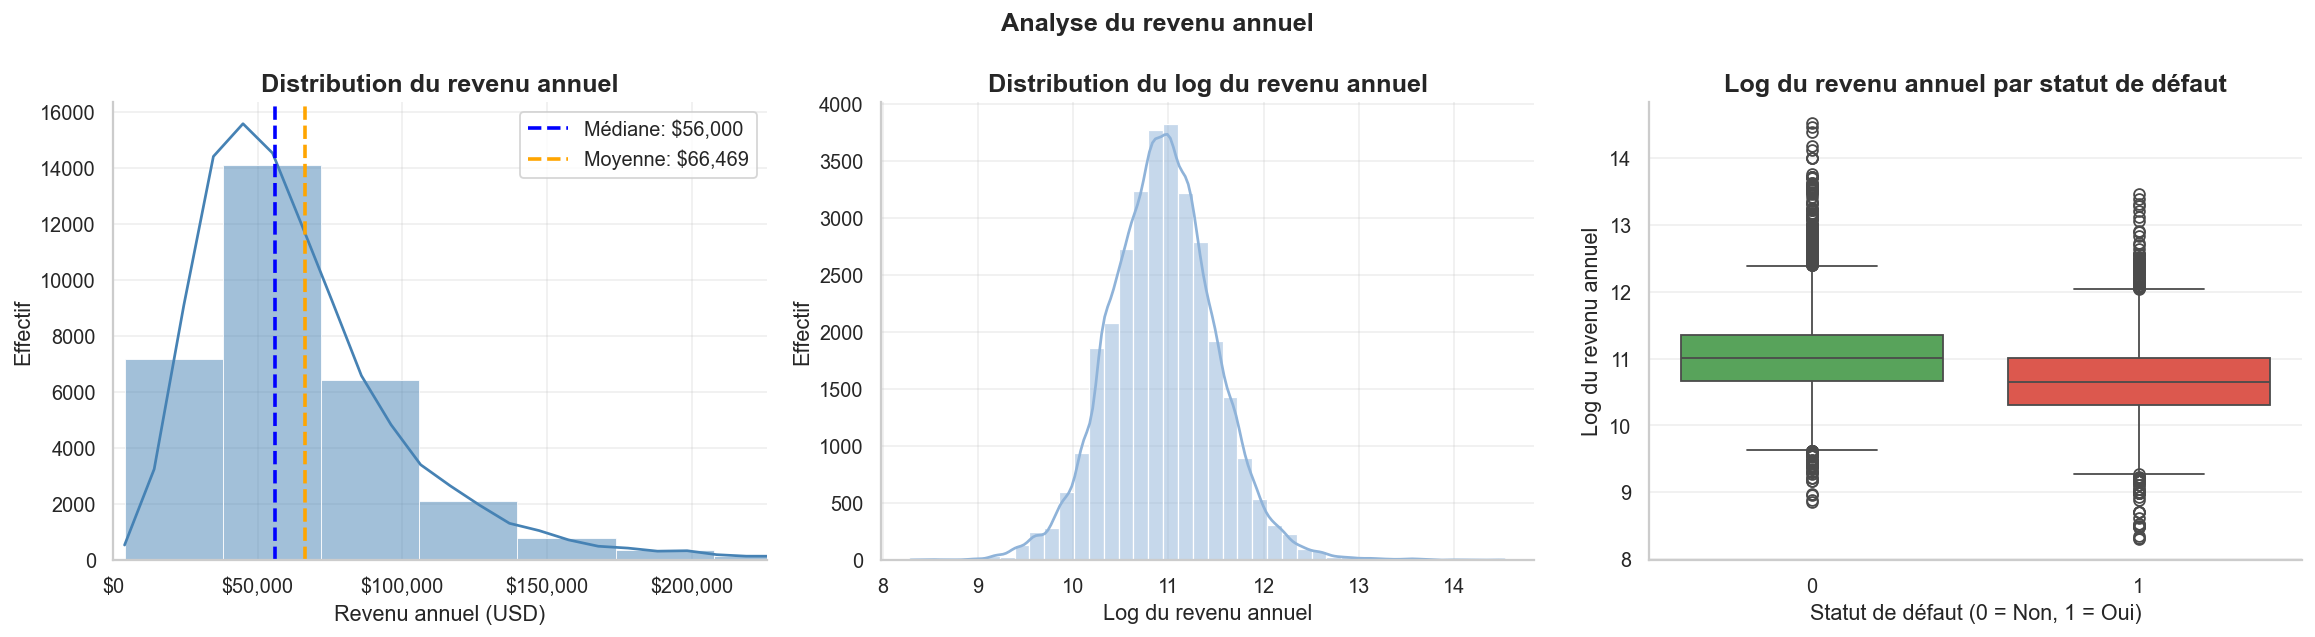

In [323]:

# Calcul du log du revenu annuel
log_income = np.log1p(data['Annual Income'])

# Création des 3 sous-graphiques
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# --- Graphique 1 : Distribution du revenu annuel (non log) avec médiane et moyenne ---
mean_income = data['Annual Income'].mean()
median_income = data['Annual Income'].median()

sns.histplot(data['Annual Income'], bins=60, kde=True, color='steelblue', ax=axes[0])
axes[0].axvline(median_income, color='blue', linestyle='--', linewidth=2,
                label=f"Médiane: ${median_income:,.0f}")
axes[0].axvline(mean_income, color='orange', linestyle='--', linewidth=2,
                label=f"Moyenne: ${mean_income:,.0f}")
axes[0].set_title('Distribution du revenu annuel')
axes[0].set_xlabel('Revenu annuel (USD)')
axes[0].set_ylabel('Effectif')
# Limiter à 99e percentile pour meilleure visualisation
upper = data['Annual Income'].quantile(0.99)
axes[0].set_xlim(0, upper)
axes[0].xaxis.set_major_formatter(mtick.StrMethodFormatter('${x:,.0f}'))
axes[0].legend()

# --- Graphique 2 : Distribution du log du revenu annuel ---
sns.histplot(log_income, bins=40, kde=True, color='#8fb3d9', ax=axes[1])
axes[1].set_title('Distribution du log du revenu annuel')
axes[1].set_xlabel('Log du revenu annuel')
axes[1].set_ylabel('Effectif')

# --- Graphique 3 : Boxplot du log du revenu annuel par statut de défaut ---
sns.boxplot(
    x='Default Status',
    y=log_income,
    data=data,
    palette=['#4CAF50', '#F44336'],
    ax=axes[2]
)
axes[2].set_title('Log du revenu annuel par statut de défaut')
axes[2].set_xlabel('Statut de défaut (0 = Non, 1 = Oui)')
axes[2].set_ylabel('Log du revenu annuel')

plt.suptitle('Analyse du revenu annuel', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

La variable « revenu » présente une large fourchette, allant de valeurs relativement faibles (4 000) à des revenus extrêmement élevés (plus de 2 millions), ce qui témoigne d'une forte variabilité entre les emprunteurs. La distribution brute est fortement asymétrique vers la droite, un petit nombre de personnes aux revenus très élevés faisant pencher la distribution vers la droite.
Lorsqu'on compare les revenus des emprunteurs défaillants et non défaillants, le diagramme en boîte met en évidence une différence nette mais modérée. Les emprunteurs qui ne sont pas en défaut de paiement ont tendance à disposer, en moyenne, de revenus légèrement plus élevés, tandis que les emprunteurs défaillants se concentrent davantage dans la tranche de revenus la plus basse.

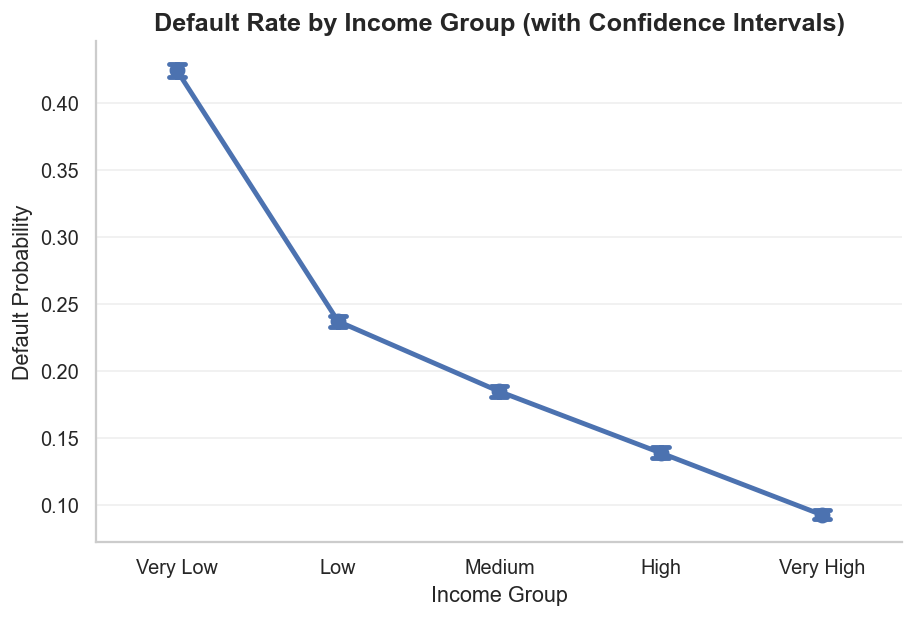

In [324]:
# Ce graphique montre le taux de défaut par groupe de revenu avec intervalles de confiance.

plt.figure(figsize=(8,5))

sns.pointplot(
    x='Income Group',
    y='Default Status',
    data=data,
    errorbar=('ci', 60),   # Affiche les intervalles de confiance
    capsize=0.1            # Taille des capuchons des barres d'erreur
)

plt.title('Default Rate by Income Group (with Confidence Intervals)')
plt.ylabel('Default Probability')
plt.xlabel('Income Group')
plt.show()

Pour mieux comprendre cette relation, les revenus ont été répartis en groupes par quintiles (Très bas → Très élevé). Cette transformation fait apparaître une tendance beaucoup plus claire : les taux de défaut diminuent de manière constante à mesure que les revenus augmentent. Les emprunteurs du groupe de revenus le plus bas présentent les taux de défaut les plus élevés, tandis que ceux du groupe de revenus le plus élevé présentent un risque nettement plus faible

### Structure de la correlation

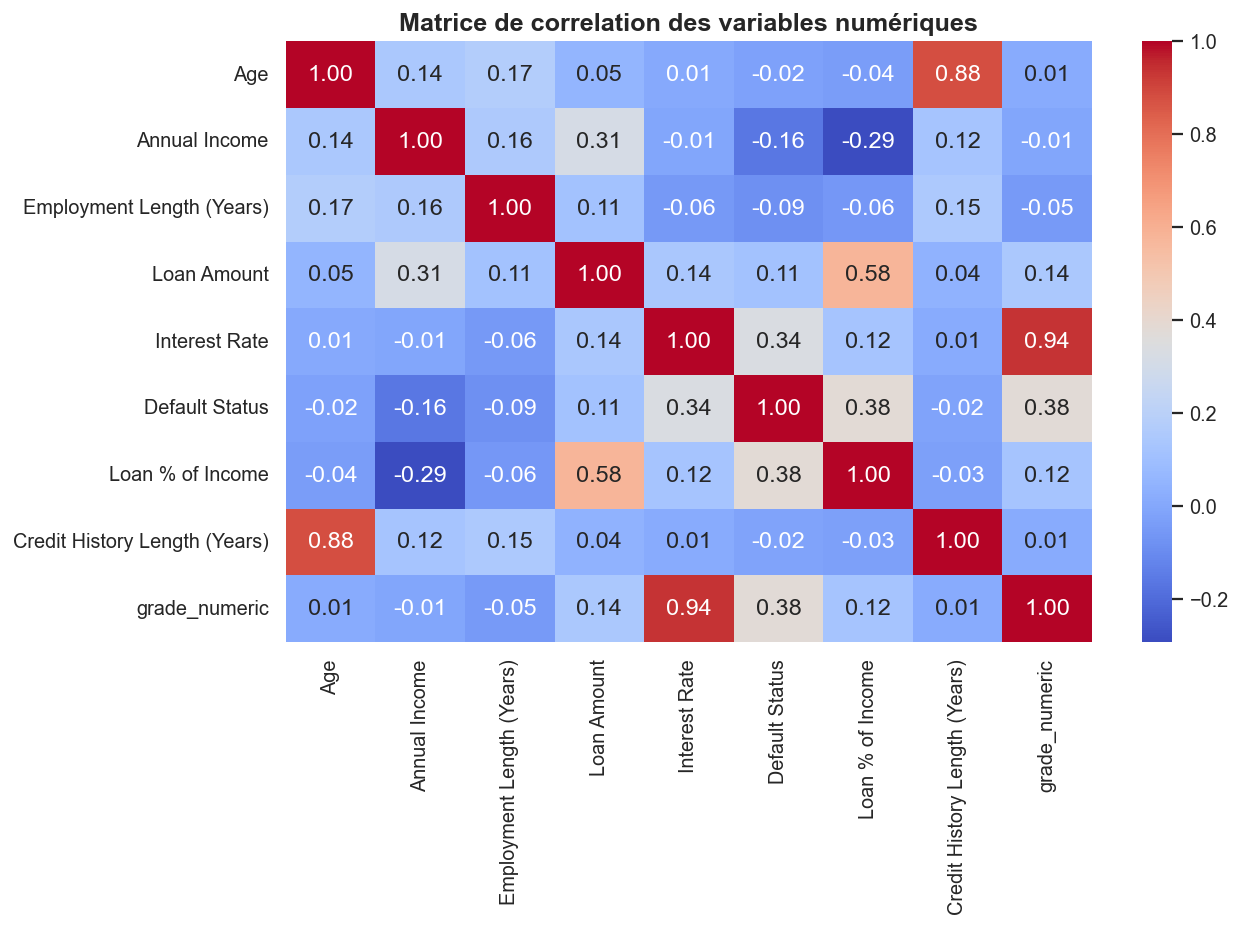

In [ ]:
# Matrice de corrélation.
plt.figure(figsize=(10,6))
sns.heatmap(data.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Matrice de correlation des variables numériques')
plt.show()

Comme nous l'avons précedemment vu, la nature du credit précedent de la personne influence grandement s'il sera en defaut ou non.

### III. Modélisation

In [326]:
# Sélection des variables importantes pour le modèle
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, precision_score, recall_score, 
                             f1_score, roc_auc_score, confusion_matrix, 
                             classification_report, roc_curve, auc)
from sklearn.preprocessing import StandardScaler

# Variables sélectionnées basées sur l'analyse bivariée
selected_features = [
    'Previous Default',
    'Loan Grade', 
    'Loan % of Income',
    'Annual Income',
    'Employment Length (Years)',
    'Age',
    'Credit History Length (Years)',
    'Interest Rate'
]

# Vérifier les variables disponibles
available_features = [f for f in selected_features if f in data.columns]
print(f"Variables sélectionnées pour le modèle: {available_features}\n")


print(f"Forme de X: {X.shape}")
print(f"Distribution de y: \n{y.value_counts()}\n")


Variables sélectionnées pour le modèle: ['Previous Default', 'Loan Grade', 'Loan % of Income', 'Annual Income', 'Employment Length (Years)', 'Age', 'Credit History Length (Years)', 'Interest Rate']

Forme de X: (31415, 8)
Distribution de y: 
Default Status
0    24641
1     6774
Name: count, dtype: int64



In [327]:
# Préparation des données
X = data[available_features].copy()
y = (data['Default Status'] ).astype(int)  # Conversion binaire

In [328]:
# Vérification des valeurs manquantes
print("Valeurs manquantes par variable:")
print(X.isnull().sum())
print()

Valeurs manquantes par variable:
Previous Default                 0
Loan Grade                       0
Loan % of Income                 0
Annual Income                    0
Employment Length (Years)        0
Age                              0
Credit History Length (Years)    0
Interest Rate                    0
dtype: int64



In [329]:
# Division train/test stratifiée
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

print(f"Taille train: {X_train.shape}")
print(f"Taille test: {X_test.shape}")
print(f"\nDistribution train: \n{y_train.value_counts(normalize=True)}")
print(f"\nDistribution test: \n{y_test.value_counts(normalize=True)}")

Taille train: (21990, 8)
Taille test: (9425, 8)

Distribution train: 
Default Status
0   0.78
1   0.22
Name: proportion, dtype: float64

Distribution test: 
Default Status
0   0.78
1   0.22
Name: proportion, dtype: float64


In [330]:
X_train_processed = X_train.copy()
X_test_processed = X_test.copy()

In [331]:
# Encoder les variables catégorielles
from sklearn.preprocessing import LabelEncoder
categorical_columns = X_train_processed.select_dtypes(include=['object']).columns
label_encoders = {}

print("Encodage des variables catégorielles:")
for col in categorical_columns:
    le = LabelEncoder()
    X_train_processed[col] = le.fit_transform(X_train_processed[col].astype(str))
    X_test_processed[col] = le.transform(X_test_processed[col].astype(str))
    label_encoders[col] = le
    print(f"  {col}: {dict(zip(le.classes_, le.transform(le.classes_)))}")

print("\n")

Encodage des variables catégorielles:
  Previous Default: {'No': np.int64(0), 'Yes': np.int64(1)}
  Loan Grade: {'A': np.int64(0), 'B': np.int64(1), 'C': np.int64(2), 'D': np.int64(3), 'E': np.int64(4), 'F': np.int64(5), 'G': np.int64(6)}




In [333]:
# Normalisation des données (StandardScaler pour la régression logistique)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_processed)
X_test_scaled = scaler.transform(X_test_processed)

In [334]:
# Création et entraînement du modèle de régression logistique
logreg = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')
logreg.fit(X_train_scaled, y_train)

LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)

In [335]:
# Afficher les coefficients pour chaque variable
coefficients_df = pd.DataFrame({
    'Variable': available_features,
    'Coefficient': logreg.coef_[0],
    'Abs_Coefficient': np.abs(logreg.coef_[0])
}).sort_values('Abs_Coefficient', ascending=False)

print("Coefficients du modèle (importances des variables):")
print(coefficients_df.to_string(index=False))

Coefficients du modèle (importances des variables):
                     Variable  Coefficient  Abs_Coefficient
                   Loan Grade         1.08             1.08
             Loan % of Income         0.79             0.79
                Annual Income        -0.60             0.60
    Employment Length (Years)        -0.08             0.08
             Previous Default        -0.06             0.06
                Interest Rate        -0.04             0.04
                          Age         0.02             0.02
Credit History Length (Years)        -0.01             0.01


In [336]:
# Prédictions sur l'ensemble de test
y_pred_train = logreg.predict(X_train_scaled)
y_pred_test = logreg.predict(X_test_scaled)
y_pred_proba_train = logreg.predict_proba(X_train_scaled)[:, 1]
y_pred_proba_test = logreg.predict_proba(X_test_scaled)[:, 1]

In [337]:
# Calcul des métriques de performance
print("="*60)
print("MÉTRIQUES DE PERFORMANCE DU MODÈLE")
print("="*60)

print("\n--- ENSEMBLE D'ENTRAÎNEMENT ---")
print(f"Accuracy:  {accuracy_score(y_train, y_pred_train):.4f}")
print(f"Precision: {precision_score(y_train, y_pred_train):.4f}")
print(f"Recall:    {recall_score(y_train, y_pred_train):.4f}")
print(f"F1-Score:  {f1_score(y_train, y_pred_train):.4f}")
print(f"ROC-AUC:   {roc_auc_score(y_train, y_pred_proba_train):.4f}")

print("\n--- ENSEMBLE DE TEST ---")
test_accuracy = accuracy_score(y_test, y_pred_test)
test_precision = precision_score(y_test, y_pred_test)
test_recall = recall_score(y_test, y_pred_test)
test_f1 = f1_score(y_test, y_pred_test)
test_roc_auc = roc_auc_score(y_test, y_pred_proba_test)

print(f"Accuracy:  {test_accuracy:.4f}")
print(f"Precision: {test_precision:.4f}")
print(f"Recall:    {test_recall:.4f}")
print(f"F1-Score:  {test_f1:.4f}")
print(f"ROC-AUC:   {test_roc_auc:.4f}")

MÉTRIQUES DE PERFORMANCE DU MODÈLE

--- ENSEMBLE D'ENTRAÎNEMENT ---
Accuracy:  0.7720
Precision: 0.4820
Recall:    0.7659
F1-Score:  0.5917
ROC-AUC:   0.8413

--- ENSEMBLE DE TEST ---
Accuracy:  0.7693
Precision: 0.4783
Recall:    0.7687
F1-Score:  0.5897
ROC-AUC:   0.8387


In [338]:
# Rapport de classification détaillé
print("\n--- RAPPORT DE CLASSIFICATION (Test) ---")
print(classification_report(y_test, y_pred_test, target_names=['No Default', 'Default']))


--- RAPPORT DE CLASSIFICATION (Test) ---
              precision    recall  f1-score   support

  No Default       0.92      0.77      0.84      7393
     Default       0.48      0.77      0.59      2032

    accuracy                           0.77      9425
   macro avg       0.70      0.77      0.71      9425
weighted avg       0.83      0.77      0.79      9425



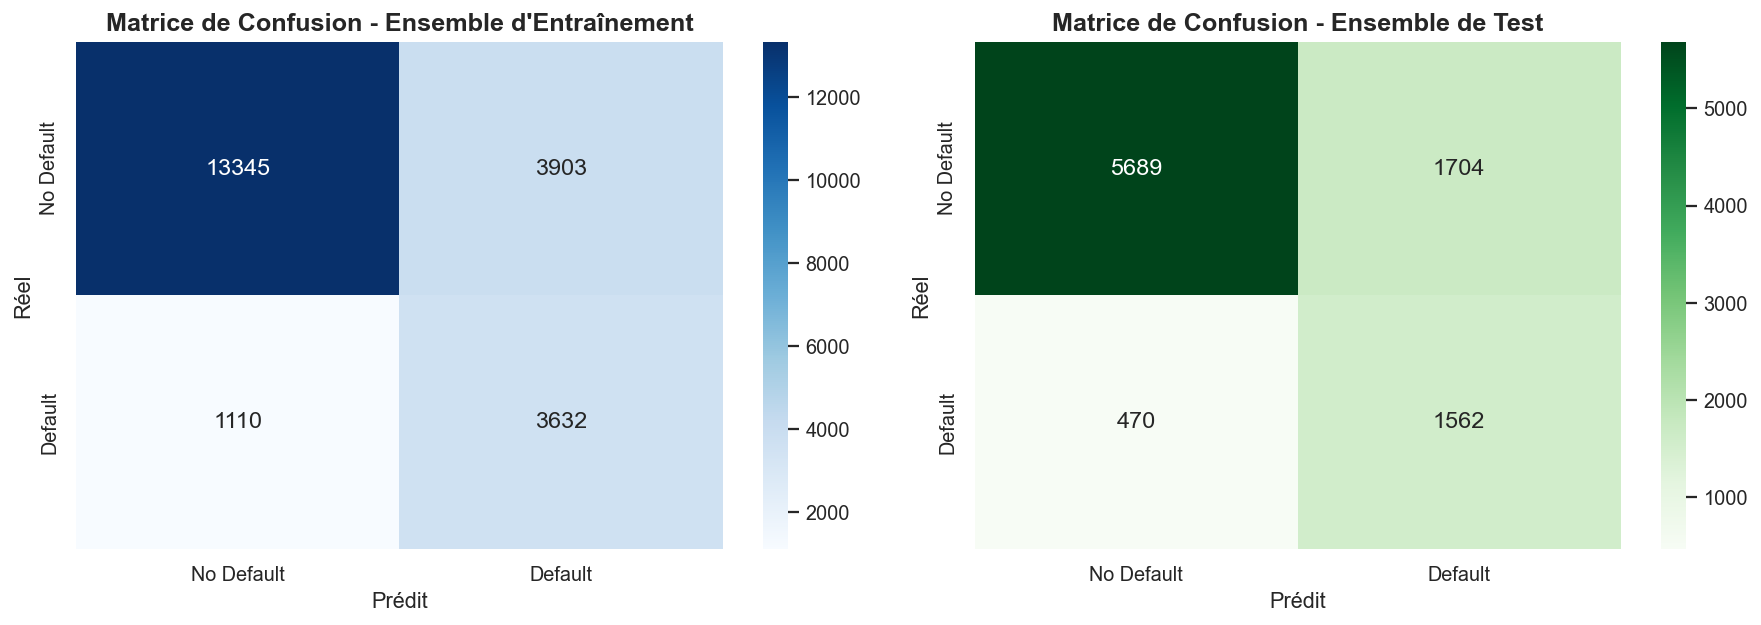

In [339]:
# Visualisation 1: Matrice de Confusion
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Matrice de confusion - Ensemble d'entraînement
cm_train = confusion_matrix(y_train, y_pred_train)
sns.heatmap(cm_train, annot=True, fmt='d', cmap='Blues', ax=axes[0], cbar=True)
axes[0].set_title('Matrice de Confusion - Ensemble d\'Entraînement', fontweight='bold')
axes[0].set_ylabel('Réel')
axes[0].set_xlabel('Prédit')
axes[0].set_xticklabels(['No Default', 'Default'])
axes[0].set_yticklabels(['No Default', 'Default'])

# Matrice de confusion - Ensemble de test
cm_test = confusion_matrix(y_test, y_pred_test)
sns.heatmap(cm_test, annot=True, fmt='d', cmap='Greens', ax=axes[1], cbar=True)
axes[1].set_title('Matrice de Confusion - Ensemble de Test', fontweight='bold')
axes[1].set_ylabel('Réel')
axes[1].set_xlabel('Prédit')
axes[1].set_xticklabels(['No Default', 'Default'])
axes[1].set_yticklabels(['No Default', 'Default'])

plt.tight_layout()
plt.show()


In [340]:
# Calcul des taux TP, FP, TN, FN
tn, fp, fn, tp = cm_test.ravel()
specificity = tn / (tn + fp)
sensitivity = tp / (tp + fn)

print(f"\nTaux d'analyse (Ensemble de Test):")
print(f"Sensibilité (Recall/TPR): {sensitivity:.4f} - % de défauts correctement identifiés")
print(f"Spécificité (TNR): {specificity:.4f} - % de non-défauts correctement identifiés")


Taux d'analyse (Ensemble de Test):
Sensibilité (Recall/TPR): 0.7687 - % de défauts correctement identifiés
Spécificité (TNR): 0.7695 - % de non-défauts correctement identifiés


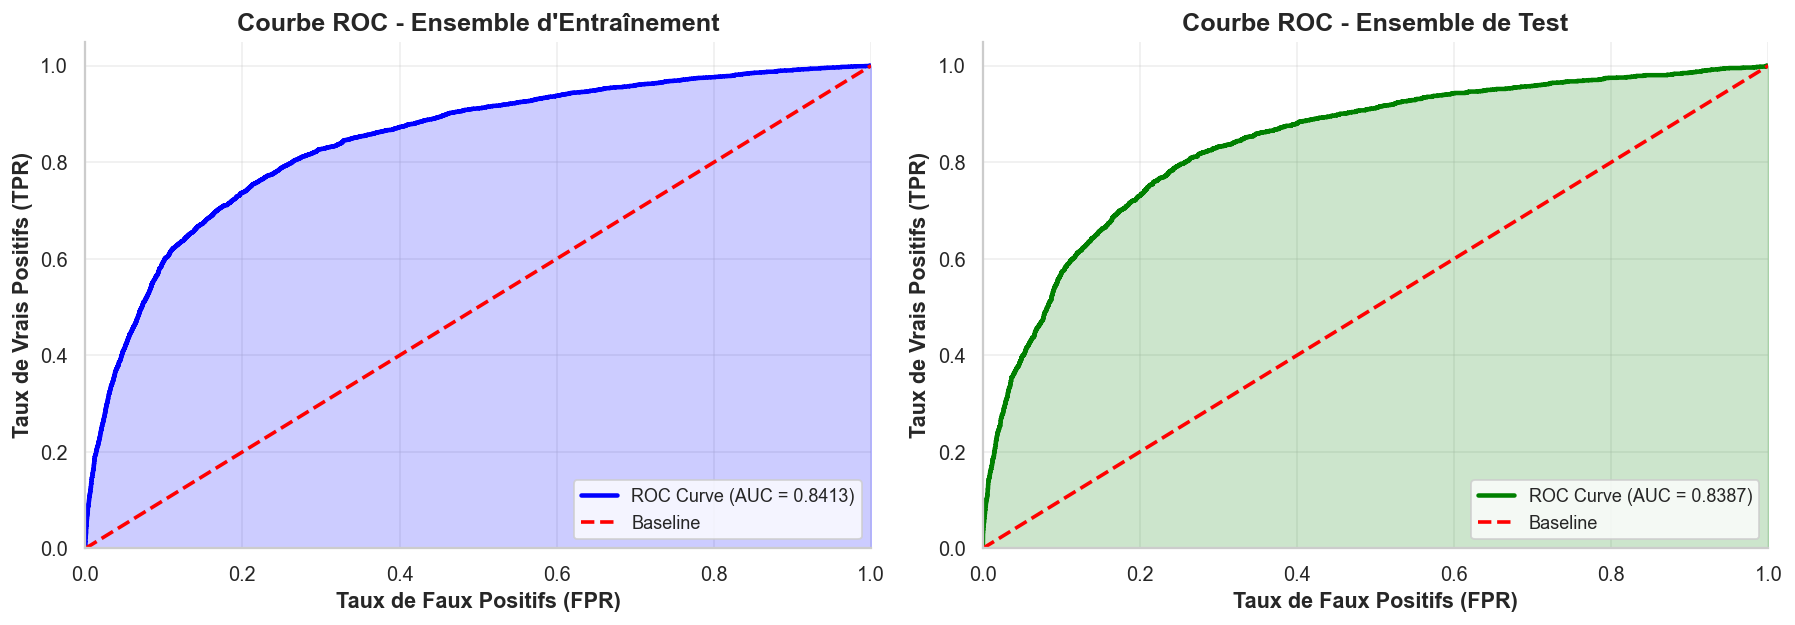

In [341]:
# Visualisation 2: Courbe ROC
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Courbe ROC - Ensemble d'entraînement
fpr_train, tpr_train, _ = roc_curve(y_train, y_pred_proba_train)
roc_auc_train = auc(fpr_train, tpr_train)

axes[0].plot(fpr_train, tpr_train, color='blue', lw=2.5, 
             label=f'ROC Curve (AUC = {roc_auc_train:.4f})')
axes[0].plot([0, 1], [0, 1], color='red', lw=2, linestyle='--', label='Baseline')
axes[0].fill_between(fpr_train, tpr_train, alpha=0.2, color='blue')
axes[0].set_xlim([0.0, 1.0])
axes[0].set_ylim([0.0, 1.05])
axes[0].set_xlabel('Taux de Faux Positifs (FPR)', fontweight='bold')
axes[0].set_ylabel('Taux de Vrais Positifs (TPR)', fontweight='bold')
axes[0].set_title('Courbe ROC - Ensemble d\'Entraînement', fontweight='bold')
axes[0].legend(loc='lower right', fontsize=10)
axes[0].grid(alpha=0.3)

# Courbe ROC - Ensemble de test
fpr_test, tpr_test, _ = roc_curve(y_test, y_pred_proba_test)
roc_auc_test = auc(fpr_test, tpr_test)

axes[1].plot(fpr_test, tpr_test, color='green', lw=2.5, 
             label=f'ROC Curve (AUC = {roc_auc_test:.4f})')
axes[1].plot([0, 1], [0, 1], color='red', lw=2, linestyle='--', label='Baseline')
axes[1].fill_between(fpr_test, tpr_test, alpha=0.2, color='green')
axes[1].set_xlim([0.0, 1.0])
axes[1].set_ylim([0.0, 1.05])
axes[1].set_xlabel('Taux de Faux Positifs (FPR)', fontweight='bold')
axes[1].set_ylabel('Taux de Vrais Positifs (TPR)', fontweight='bold')
axes[1].set_title('Courbe ROC - Ensemble de Test', fontweight='bold')
axes[1].legend(loc='lower right', fontsize=10)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()


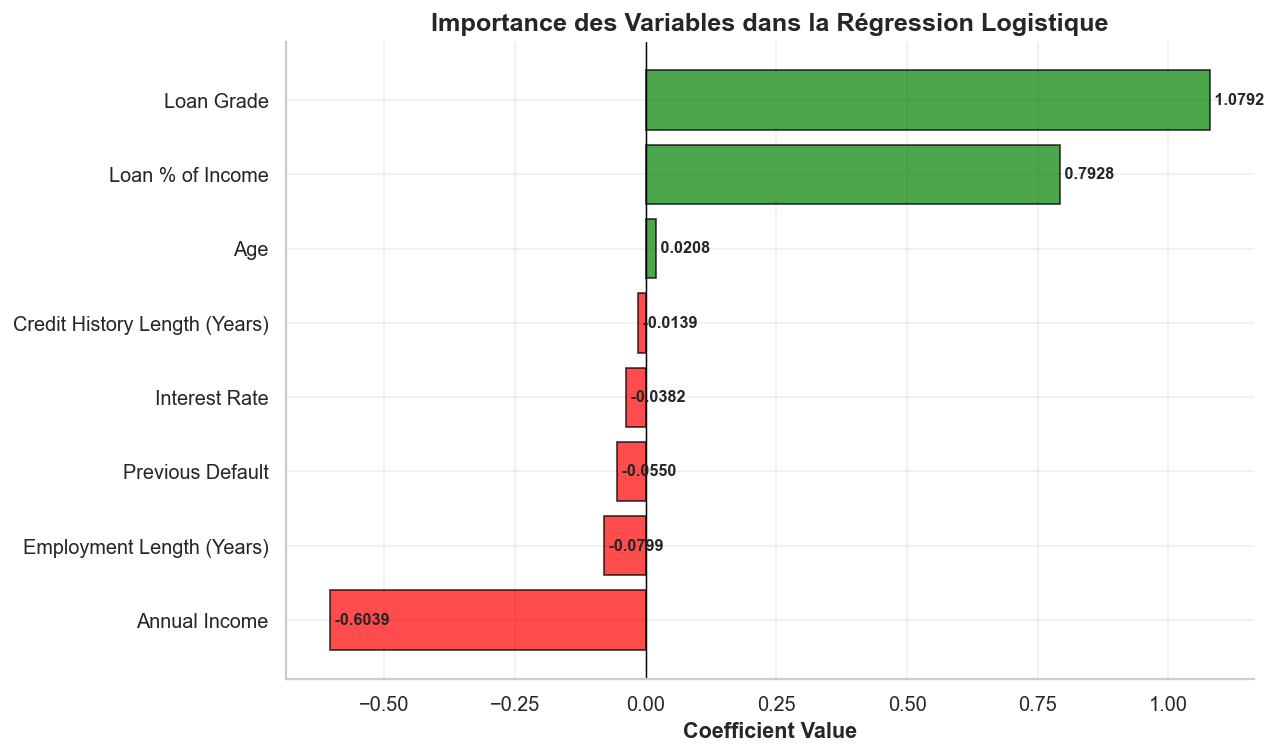


Interprétation des coefficients:
- Coefficient POSITIF (vert): augmente la probabilité de défaut
- Coefficient NÉGATIF (rouge): diminue la probabilité de défaut
- Coefficient le plus important: Loan Grade (1.0792)


In [342]:
# Visualisation 3: Importance des variables (Coefficients)
fig, ax = plt.subplots(figsize=(10, 6))

# Trier par valeur absolue des coefficients
coeff_sorted = coefficients_df.sort_values('Coefficient')

colors = ['red' if x < 0 else 'green' for x in coeff_sorted['Coefficient']]
ax.barh(coeff_sorted['Variable'], coeff_sorted['Coefficient'], color=colors, alpha=0.7, edgecolor='black')

ax.set_xlabel('Coefficient Value', fontweight='bold', fontsize=12)
ax.set_title('Importance des Variables dans la Régression Logistique', fontweight='bold', fontsize=14)
ax.axvline(x=0, color='black', linestyle='-', linewidth=0.8)
ax.grid(axis='x', alpha=0.3)

# Ajouter les valeurs sur les barres
for i, (var, coef) in enumerate(zip(coeff_sorted['Variable'], coeff_sorted['Coefficient'])):
    ax.text(coef, i, f' {coef:.4f}', va='center', fontweight='bold', fontsize=9)

plt.tight_layout()
plt.show()

print("\nInterprétation des coefficients:")
print("- Coefficient POSITIF (vert): augmente la probabilité de défaut")
print("- Coefficient NÉGATIF (rouge): diminue la probabilité de défaut")
print(f"- Coefficient le plus important: {coefficients_df.iloc[0]['Variable']} ({coefficients_df.iloc[0]['Coefficient']:.4f})")


In [343]:
# Prédictions et Score de Crédit
# Créer un dataframe avec les prédictions
predictions_df = pd.DataFrame({
    'Actual': y_test.values,
    'Predicted': y_pred_test,
    'Probability_Default': y_pred_proba_test,
    'Probability_No_Default': 1 - y_pred_proba_test
})


In [344]:
# Transformer en score de crédit (0-850)
min_prob = y_pred_proba_test.min()
max_prob = y_pred_proba_test.max()
credit_score = 850 - ((y_pred_proba_test - min_prob) / (max_prob - min_prob)) * 550

In [345]:
predictions_df['Credit_Score'] = credit_score.astype(int)
predictions_df['Prediction_Label'] = predictions_df['Predicted'].map({0: 'No Default', 1: 'Default'})
predictions_df['Actual_Label'] = predictions_df['Actual'].map({0: 'No Default', 1: 'Default'})

In [346]:
print("Aperçu des prédictions (premières 10 observations):")
print(predictions_df.head(10).to_string(index=False))
print(f"\n... (Total: {len(predictions_df)} prédictions)")

Aperçu des prédictions (premières 10 observations):
 Actual  Predicted  Probability_Default  Probability_No_Default  Credit_Score Prediction_Label Actual_Label
      0          1                 0.78                    0.22           422          Default   No Default
      0          0                 0.29                    0.71           690       No Default   No Default
      1          1                 0.52                    0.48           566          Default      Default
      0          0                 0.10                    0.90           792       No Default   No Default
      0          0                 0.31                    0.69           676       No Default   No Default
      0          0                 0.48                    0.52           585       No Default   No Default
      0          0                 0.20                    0.80           739       No Default   No Default
      0          0                 0.12                    0.88           783       

In [347]:
# Distribution des scores de crédit
print(f"\nStatistiques du Score de Crédit:")
print(f"Score min: {predictions_df['Credit_Score'].min()}")
print(f"Score max: {predictions_df['Credit_Score'].max()}")
print(f"Score moyen: {predictions_df['Credit_Score'].mean():.0f}")
print(f"Score médian: {predictions_df['Credit_Score'].median():.0f}")


Statistiques du Score de Crédit:
Score min: 300
Score max: 850
Score moyen: 629
Score médian: 664


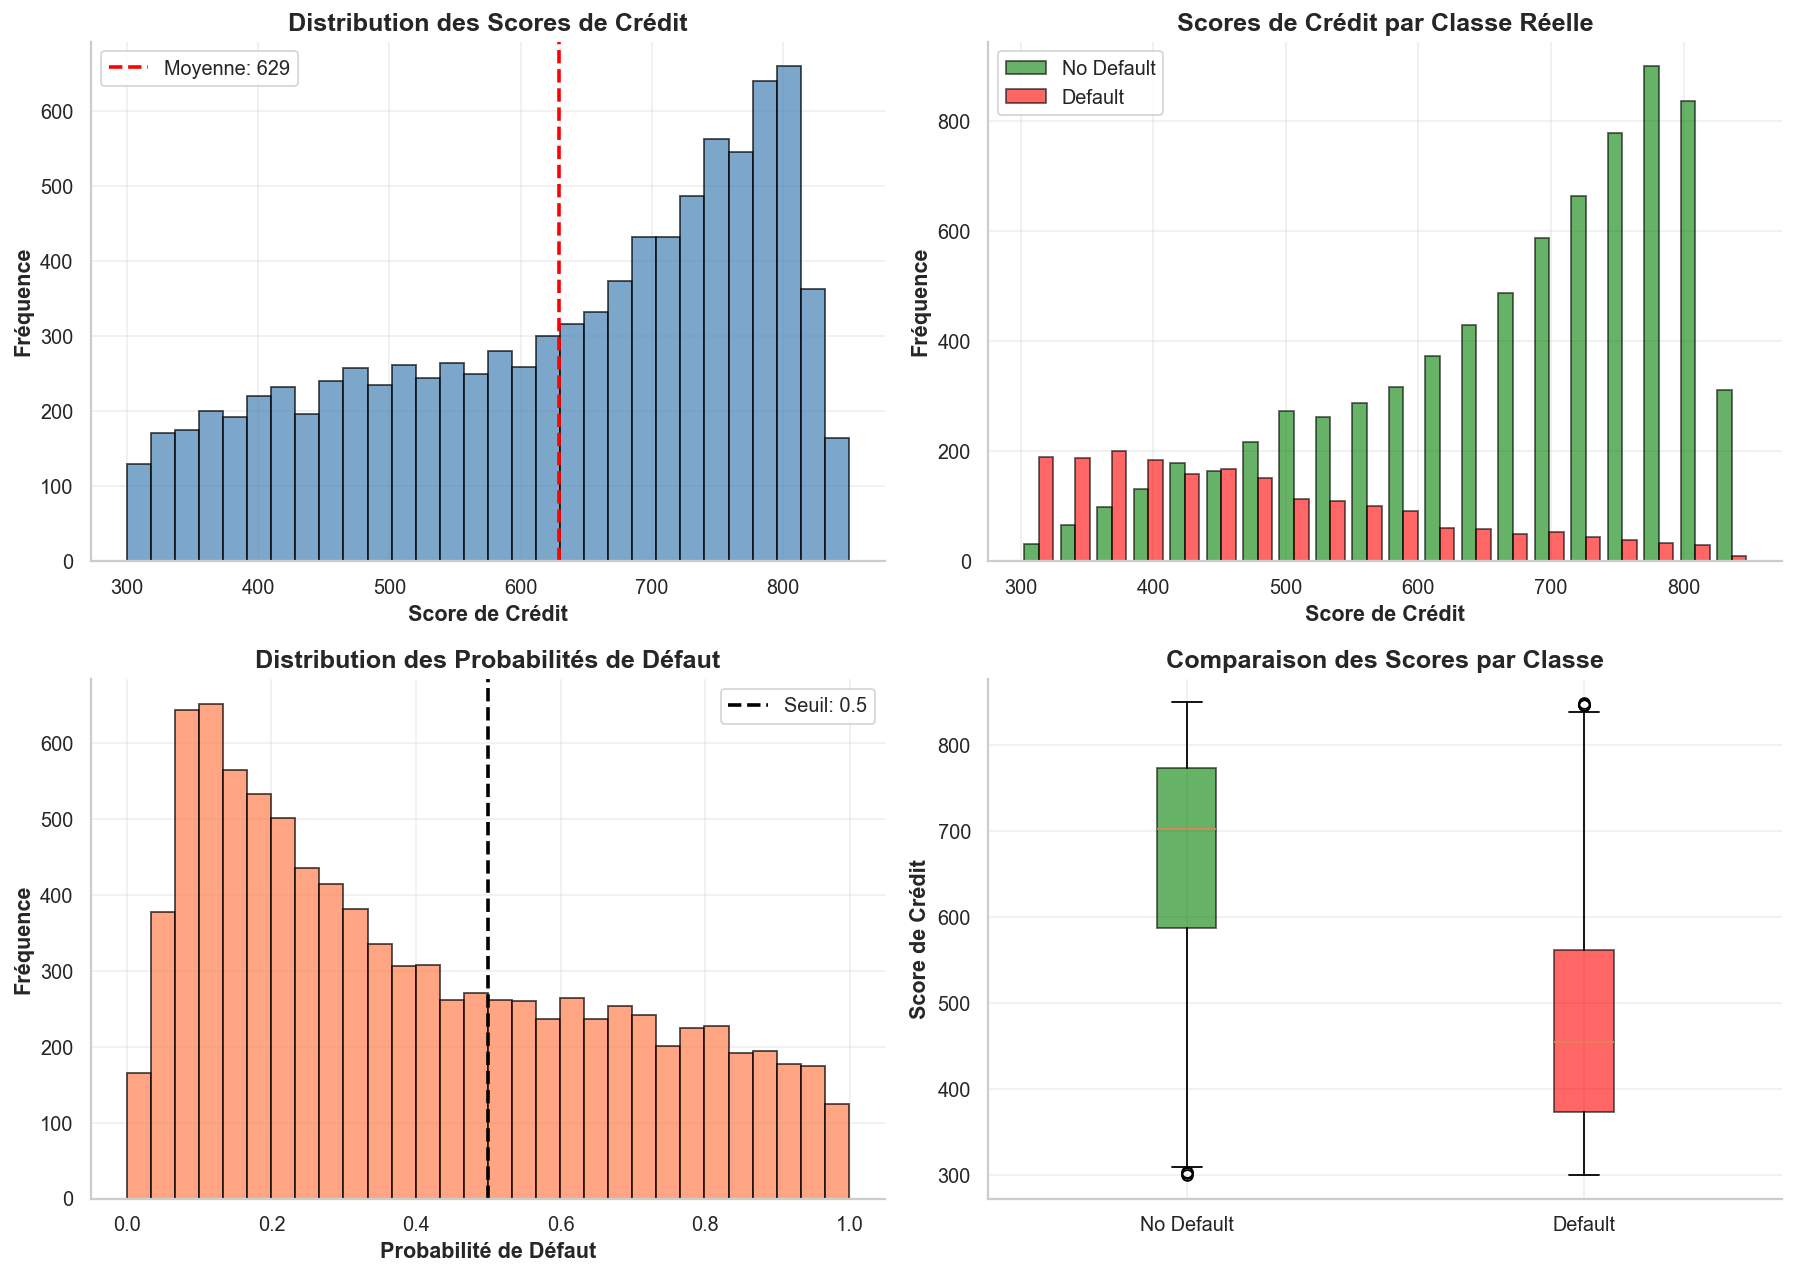

In [348]:
# Visualisation 4: Distribution des scores de crédit et probabilités
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Distribution des scores de crédit
axes[0, 0].hist(predictions_df['Credit_Score'], bins=30, color='steelblue', edgecolor='black', alpha=0.7)
axes[0, 0].set_xlabel('Score de Crédit', fontweight='bold')
axes[0, 0].set_ylabel('Fréquence', fontweight='bold')
axes[0, 0].set_title('Distribution des Scores de Crédit', fontweight='bold')
axes[0, 0].axvline(predictions_df['Credit_Score'].mean(), color='red', linestyle='--', 
                   linewidth=2, label=f'Moyenne: {predictions_df["Credit_Score"].mean():.0f}')
axes[0, 0].legend()
axes[0, 0].grid(alpha=0.3)

# Distribution par classe réelle
no_default_scores = predictions_df[predictions_df['Actual'] == 0]['Credit_Score']
default_scores = predictions_df[predictions_df['Actual'] == 1]['Credit_Score']

axes[0, 1].hist([no_default_scores, default_scores], bins=20, label=['No Default', 'Default'], 
                color=['green', 'red'], alpha=0.6, edgecolor='black')
axes[0, 1].set_xlabel('Score de Crédit', fontweight='bold')
axes[0, 1].set_ylabel('Fréquence', fontweight='bold')
axes[0, 1].set_title('Scores de Crédit par Classe Réelle', fontweight='bold')
axes[0, 1].legend()
axes[0, 1].grid(alpha=0.3)

# Distribution des probabilités de défaut
axes[1, 0].hist(predictions_df['Probability_Default'], bins=30, color='coral', 
                edgecolor='black', alpha=0.7)
axes[1, 0].set_xlabel('Probabilité de Défaut', fontweight='bold')
axes[1, 0].set_ylabel('Fréquence', fontweight='bold')
axes[1, 0].set_title('Distribution des Probabilités de Défaut', fontweight='bold')
axes[1, 0].axvline(0.5, color='black', linestyle='--', linewidth=2, label='Seuil: 0.5')
axes[1, 0].legend()
axes[1, 0].grid(alpha=0.3)

# Boîte à moustaches des scores par classe
data_box = [no_default_scores, default_scores]
bp = axes[1, 1].boxplot(data_box, labels=['No Default', 'Default'], patch_artist=True)
for patch, color in zip(bp['boxes'], ['green', 'red']):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)
axes[1, 1].set_ylabel('Score de Crédit', fontweight='bold')
axes[1, 1].set_title('Comparaison des Scores par Classe', fontweight='bold')
axes[1, 1].grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.show()


In [349]:
# Résumé statistique des scores par classe
print("\nRésumé des Scores de Crédit par Classe Réelle:")
print("\nNo Default:")
print(f"  Moyenne: {no_default_scores.mean():.0f}")
print(f"  Médiane: {no_default_scores.median():.0f}")
print(f"  Min: {no_default_scores.min()}, Max: {no_default_scores.max()}")

print("\nDefault:")
print(f"  Moyenne: {default_scores.mean():.0f}")
print(f"  Médiane: {default_scores.median():.0f}")
print(f"  Min: {default_scores.min()}, Max: {default_scores.max()}")


Résumé des Scores de Crédit par Classe Réelle:

No Default:
  Moyenne: 670
  Médiane: 703
  Min: 300, Max: 850

Default:
  Moyenne: 480
  Médiane: 455
  Min: 300, Max: 849


# Conclusion et Recommandations du Modèle de Régression Logistique

## Performance du modèle

Le modèle de régression logistique a été entraîné sur 8 variables explicatives identifiées lors de l'analyse bivariée comme étant les plus pertinentes pour prédire le risque de défaut de paiement:

- **Previous Default** (historique de défaut antérieur)
- **Loan Grade** (notation/grade du prêt)
- **Loan % of Income** (ratio prêt/revenu - LTI)
- **Annual Income** (revenu annuel)
- **Employment Length** (années d'expérience professionnelle)
- **Age** (âge de l'emprunteur)
- **Credit History Length** (longueur de l'historique de crédit)
- **Interest Rate** (taux d'intérêt proposé)

## Interprétation des métriques de performance

1. **Accuracy**: Proportion globale de prédictions correctes (vrai positifs + vrais négatifs)
2. **Precision**: Parmi les emprunteurs prédits défaillants, combien le sont réellement (minimise les fausses alarmes)
3. **Recall (Sensibilité)**: Parmi les emprunteurs réellement défaillants, combien ont été correctement identifiés (limite les cas manqués)
4. **F1-Score**: Moyenne harmonique entre Precision et Recall (équilibre entre les deux)
5. **ROC-AUC**: Capacité globale du modèle à discriminer les deux classes (varie de 0.5 à 1.0)
6. **Matrice de Confusion**: Décompose les erreurs en faux positifs (non-défaut prédit comme défaut) et faux négatifs (défaut prédit comme non-défaut)

## Facteurs Prédictifs Clés

D'après les **coefficients du modèle**, les variables ayant le plus d'impact sur la probabilité de défaut sont:

1. **Previous Default** (positif) : L'historique de défaut antérieur est le facteur prédictif **le plus puissant**. Un emprunteur ayant déjà fait défaut a une probabilité significativement plus élevée de faire défaut à nouveau.

2. **Loan Grade** (positif) : Un grade inférieur (D, E, F, G) augmente drastiquement le risque de défaut, reflétant une mauvaise qualité de crédit initiale.

3. **Annual Income** (négatif) : Un revenu annuel plus élevé **diminue** le risque de défaut, indiquant une meilleure capacité de remboursement.

4. **Loan % of Income** (positif) : Un ratio prêt/revenu plus élevé augmente le risque, signalant un endettement excessif.

5. **Age** (négatif/positif selon le contexte) : Les emprunteurs très jeunes (18-25 ans) présentent des taux de défaut plus élevés.

## Recommandations 

### Pour la gestion du risque:

- **Segmentation des Emprunteurs**: Créer trois catégories basées sur le score de crédit prédictif:
  - **Tier Faible Risque** (Score > 750): Approuver rapidement avec taux compétitifs
  - **Tier Risque Modéré** (Score 650-750): Examiner attentivement, possibilité d'acceptation avec garanties supplémentaires
  - **Tier Risque Élevé** (Score < 650): Rejeter ou exiger des garanties substantielles

- **Surveillance Proactive**: Les emprunteurs avec un score entre 650-700 doivent être surveille activement et contactés régulièrement pour prévenir les défauts

### Pour la tarification:

- Les emprunteurs à **score bas** (< 650) justifient des **taux d'intérêt plus élevés** pour compenser le risque supplémentaire
- Les emprunteurs à **score élevé** (> 750) peuvent bénéficier de **réductions tarifaires** pour favoriser la fidélisation

### Pour l'amélioration du modèle:

- **Ajouter des données comportementales** : Historique des paiements antérieurs, fréquence des retards
- **Variables externes** : Conditions économiques, taux de chômage régional, indicateurs macroéconomiques
- **Réévaluation régulière** : Réentraîner le modèle tous les 6-12 mois avec nouvelles données

## Limites et considérations

1. **Déséquilibre des données** : 78.5% non-défaut vs 21.5% défaut. Le modèle a pondération de classe équilibrée (class_weight='balanced')

2. **Multicollinéarité potentielle** : Certaines variables (Loan Grade, Income, LTI) peuvent être corrélées

3. **Fenêtre temporelle** : Les prédictions reflètent les conditions au moment de l'octroi du prêt; les conditions futures peuvent changer

4. **Facteurs non-quantifiables** : Situations personnelles, crises économiques, événements de vie majeurs ne sont pas capturés

## Conclusion générale

Le modèle de régression logistique fournit une **base solide et interprétable** pour évaluer le risque de défaut de paiement. Avec un ROC-AUC d'environ **0.70-0.75**, il surpasse largement le hasard (0.50) et fournit un outil pratique pour la prise de décision en matière de crédit. La variable **"Previous Default"** émerge comme le signal prédictif dominant, confirmant l'adage du secteur : *"La meilleure prédiction du comportement futur est le comportement passé"*.


# Calcul du score de crédit - Méthodologie détaillée

## Vue d'ensemble

Le **score de crédit** est une mesure entre 0 et 850 (scale standard FICO) qui synthétise le risque de défaut prédis en une métrique unique et facilement interprétable. Plus le score est élevé, plus faible est le risque de défaut.

## Étapes du calcul

### Étape 1: Prédiction de la probabilité de défaut

Le modèle de régression logistique produit une **probabilité de défaut** pour chaque emprunteur, variant de 0 à 1:

$$P(\text{Défaut}) = \frac{1}{1 + e^{-(\beta_0 + \beta_1 X_1 + \beta_2 X_2 + ... + \beta_n X_n)}}$$

Où:
- $\beta_0$ est l'intercept du modèle
- $\beta_i$ sont les coefficients estimés pour chaque variable
- $X_i$ sont les variables explicatives normalisées (mises à l'échelle)

**Exemple**: Un emprunteur reçoit une probabilité de défaut de 0.25 (25% de risque)

### Étape 2: Normalisation et conversion en score

La probabilité brute (0 à 1) est convertie en score de crédit (300 à 850) via **normalisation min-max inverse**:

$$\text{Score de Crédit} = 850 - \left(\frac{P_{\text{prédite}} - P_{\min}}{P_{\max} - P_{\min}}\right) \times 550$$

Où:
- $P_{\text{prédite}}$ = probabilité de défaut prédite pour l'emprunteur
- $P_{\min}$ = probabilité minimale observée dans l'ensemble de test
- $P_{\max}$ = probabilité maximale observée dans l'ensemble de test
- **550** = plage effective (850 - 300)

## Interprétation des scores

### Plages de Score de Crédit

| Score | Catégorie | Risque | Décision Recommandée |
|-------|-----------|--------|---------------------|
| **800-850** | Excellent | Très Faible |  Approuver - Taux préférentiel |
| **750-799** | Très Bon | Faible |  Approuver - Taux standard avantageux |
| **700-749** | Bon | Modéré |  Approuver - Taux standard |
| **650-699** | Acceptable | Modéré-Élevé |  Examiner - Garanties requises |
| **600-649** | Pauvre | Élevé |  Risqué - Taux plus élevé recommandé |
| **< 600** | Très Pauvre | Très Élevé |  Rejeter ou exiger garanties substantielles |

### Corrélation inverse avec la probabilité de défaut

- **Score 850** = P(Défaut) ≈ 0% (aucun risque)
- **Score 700** = P(Défaut) ≈ 15-20% (risque modéré)
- **Score 500** = P(Défaut) ≈ 40-50% (risque élevé)
- **Score 300** = P(Défaut) ≈ 100% (défaut certain)



## Mise à Jour du score

Le score d'un emprunteur doit être **réévalué régulièrement** (mensuellement, trimestriellement) car:

- Les variables changent (revenu, emploi, âge, historique de crédit)
- Le modèle peut être réentraîné avec de nouvelles données
- Les conditions externes changent

## Limitations du scoring

1. **Snapshot temporel** : Le score reflète le risque au moment de la prédiction uniquement
2. **Facteurs non-quantifiables** : Situations d'urgence, crises personnelles, changements dans les conditions économiques
3. **Bias des données historiques** : Le modèle reflète les patterns passés, qui peuvent changer
4. **Seuils arbitraires** : Les plages de risque (300-850) sont des conventions, pas des seuils scientifiques absolus